In [1]:
# ============================================
# Step 1: Mount Google Drive and Load Dataset
# ============================================

from google.colab import drive
import pandas as pd
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define file path (update this to match your actual path)
file_path = '/content/drive/My Drive/6165 group/cleaned_amazon_random_reviews.csv'

# Check if file exists
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"✅ Successfully loaded {len(df)} reviews")

    # Display first few rows to verify
    print("\nFirst 5 rows:")
    print(df.head())

    # Check rating distribution
    print("\nRating distribution:")
    print(df['rating'].value_counts().sort_index())

    # ============================================
    # Step 2: Balanced Sampling
    # ============================================
    print("\n" + "="*50)
    print("Balanced Sampling")
    print("="*50)

    # Sample 5,000 positive reviews (5-star)
    df_5star = df[df['rating'] == 5].sample(n=5000, random_state=42)

    # Sample 5,000 negative reviews (1-2 star)
    df_12star = df[df['rating'] <= 2].sample(n=5000, random_state=42)

    print(f"5-star reviews sampled: {len(df_5star)}")
    print(f"1-2 star reviews sampled: {len(df_12star)}")

    # Combine into target dataframe
    target_df = pd.concat([df_5star, df_12star]).reset_index(drop=True)
    print(f"Total sampled reviews: {len(target_df)}")

    # Preview
    print("\nPreview of sampled data:")
    text_col = 'clean_text_final' if 'clean_text_final' in target_df.columns else 'text'
    print(target_df[['rating', text_col]].head())

    # Save sampled data
    target_df.to_csv('sampled_5k_pos_5k_neg.csv', index=False)
    print("\n✅ Sampled data saved to: sampled_5k_pos_5k_neg.csv")

else:
    print(f"❌ File not found at: {file_path}")
    print("\nPlease check:")
    print("1. Your Google Drive is mounted correctly")
    print("2. The file path is correct")
    print("3. The file name matches exactly")

    # List files in the directory to help debug
    drive_path = '/content/drive/My Drive/6165 group/'
    if os.path.exists(drive_path):
        print(f"\nFiles in {drive_path}:")
        print(os.listdir(drive_path))

Mounted at /content/drive
✅ Successfully loaded 46361 reviews

First 5 rows:
   rating                               title  \
0     1.0  Poor packaging and arrived Damaged   
1     5.0                          Five Stars   
2     5.0                            Go Dawgs   
3     5.0                       It’s perfect!   
4     5.0                       Great product   

                                                text  \
0  the pot was only wrapped in a plastic courier ...   
1                     awesome belt. very heavy duty.   
2                                    very well made.   
3  we love this bike! well buy a second for our y...   
4                    better than i expected quality!   

                                              images        asin parent_asin  \
0  [{'small_image_url': 'https://m.media-amazon.c...  B0002CX9FE  B0002CX9FE   
1                                                 []  B06XFW4HNY  B06XFW4HNY   
2                                                 [

In [2]:
# ============================================
# Step 3: BERT Embeddings Generation
# ============================================

from sentence_transformers import SentenceTransformer
import numpy as np
import time

print("="*50)
print("Step 3: Generating BERT Embeddings")
print("="*50)

# Load the sampled data (or use target_df from previous step)
# If you're starting fresh, load the saved file
# target_df = pd.read_csv('sampled_5k_pos_5k_neg.csv')

# Check which text column to use
if 'clean_text_final' in target_df.columns:
    text_col = 'clean_text_final'
    print(f"Using preprocessed text: {text_col}")
elif 'clean_text' in target_df.columns:
    text_col = 'clean_text'
    print(f"Using cleaned text: {text_col}")
else:
    text_col = 'text'
    print(f"Using original text: {text_col}")

# Prepare texts
texts = target_df[text_col].astype(str).tolist()
print(f"\nTotal texts to encode: {len(texts)}")

# Load Sentence-BERT model
print("\nLoading Sentence-BERT model 'all-MiniLM-L6-v2'...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("✅ Model loaded successfully")

# Generate embeddings
print("\nGenerating embeddings (this may take 10-15 minutes)...")
start_time = time.time()

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=32,  # Adjust based on your GPU memory
    convert_to_numpy=True
)

end_time = time.time()
print(f"\n✅ Embeddings generated in {end_time - start_time:.2f} seconds")
print(f"Embeddings shape: {embeddings.shape}")

# Save embeddings for later use (so you don't have to re-run)
np.save('bert_embeddings_10k.npy', embeddings)
print("\n✅ Embeddings saved to: bert_embeddings_10k.npy")

#  Quick sanity check
print("\nSanity check - First embedding vector (first 10 dimensions):")
print(embeddings[0][:10])

Step 3: Generating BERT Embeddings
Using preprocessed text: clean_text_final

Total texts to encode: 10000

Loading Sentence-BERT model 'all-MiniLM-L6-v2'...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded successfully

Generating embeddings (this may take 10-15 minutes)...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]


✅ Embeddings generated in 177.18 seconds
Embeddings shape: (10000, 384)

✅ Embeddings saved to: bert_embeddings_10k.npy

Sanity check - First embedding vector (first 10 dimensions):
[ 0.00476059 -0.0329125  -0.01203276 -0.00057439  0.02053721 -0.03765813
  0.0300119   0.1156172   0.02498327  0.02364979]


Step 4: Running UMAP & K-Means Clustering
Reducing dimensions using UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ UMAP reduction complete.
Clustering reviews into 6 themes...
✅ Clustering complete.


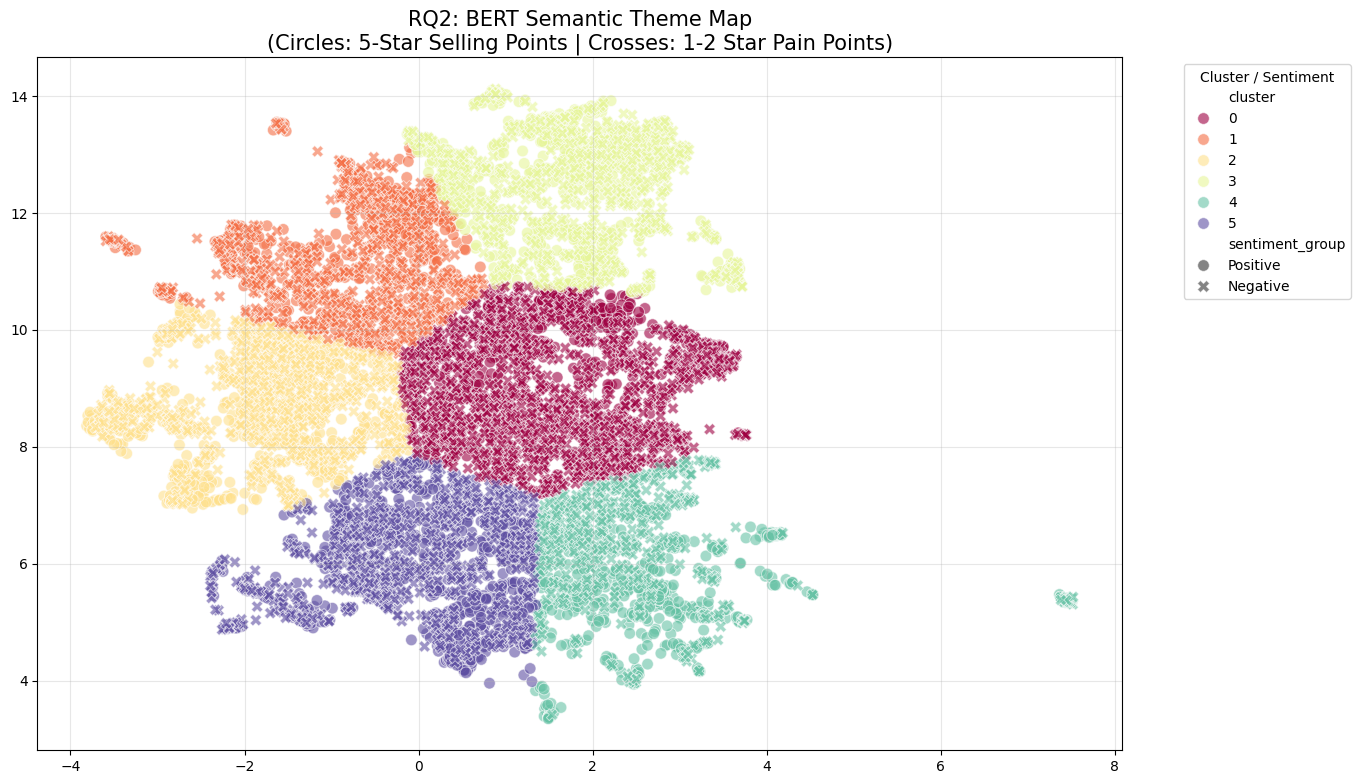


MARKETING INSIGHTS: CLUSTER ANALYSIS

[Theme Cluster 0]
Top Keywords: would, return, first, realli, purchas, month, broke
Negative Ratio: 64.1%
Business Insight: ⚖️ MIXED FEEDBACK (Feature Evaluation)

[Theme Cluster 1]
Top Keywords: would, strap, first, pocket, qualiti, realli, perfect
Negative Ratio: 51.0%
Business Insight: ⚖️ MIXED FEEDBACK (Feature Evaluation)

[Theme Cluster 2]
Top Keywords: light, would, batteri, wheel, first, littl, replac
Negative Ratio: 50.2%
Business Insight: ⚖️ MIXED FEEDBACK (Feature Evaluation)

[Theme Cluster 3]
Top Keywords: water, bottl, would, realli, purchas, recommend, perfect
Negative Ratio: 50.1%
Business Insight: ⚖️ MIXED FEEDBACK (Feature Evaluation)

[Theme Cluster 4]
Top Keywords: price, qualiti, purchas, money, expect, would, perfect
Negative Ratio: 38.4%
Business Insight: ⚖️ MIXED FEEDBACK (Feature Evaluation)

[Theme Cluster 5]
Top Keywords: qualiti, perfect, would, color, small, order, comfort
Negative Ratio: 38.8%
Business Insight: ⚖️ MIX

In [3]:
# ==============================================================================
# STEP 4: DIMENSIONALITY REDUCTION & SEMANTIC CLUSTERING (RQ2)
# ==============================================================================

# Install UMAP if needed: !pip install umap-learn
import umap
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

print("="*50)
print("Step 4: Running UMAP & K-Means Clustering")
print("="*50)

# Create sentiment_group column for visualization
target_df['sentiment_group'] = target_df['rating'].apply(
    lambda x: 'Positive' if x >= 4 else 'Negative'
)

# 1. UMAP Dimensionality Reduction
print("Reducing dimensions using UMAP...")
reducer = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    metric='cosine',
    random_state=42
)
umap_embeddings = reducer.fit_transform(embeddings)
print("✅ UMAP reduction complete.")

# 2. K-Means Clustering
n_clusters = 6
print(f"Clustering reviews into {n_clusters} themes...")
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
target_df['cluster'] = kmeans.fit_predict(umap_embeddings)
print("✅ Clustering complete.")

# 3. Visualization: Semantic Map
plt.figure(figsize=(14, 9))
markers = {"Positive": "o", "Negative": "X"}

sns.scatterplot(
    x=umap_embeddings[:, 0],
    y=umap_embeddings[:, 1],
    hue=target_df['cluster'],
    style=target_df['sentiment_group'],
    markers=markers,
    palette='Spectral',
    alpha=0.6,
    s=70
)

plt.title("RQ2: BERT Semantic Theme Map\n(Circles: 5-Star Selling Points | Crosses: 1-2 Star Pain Points)", fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Cluster / Sentiment")
plt.grid(True, alpha=0.3)
plt.show()

# 4. Automated Business Insight Extraction
print("\n" + "="*50)
print("MARKETING INSIGHTS: CLUSTER ANALYSIS")
print("="*50)

stop_words = {'great', 'good', 'love', 'nice', 'product', 'item', 'work', 'really', 'quality', 'bought', 'amazon', 'clean_text_final'}

for i in range(n_clusters):
    cluster_subset = target_df[target_df['cluster'] == i]
    neg_rate = (cluster_subset['sentiment_group'] == 'Negative').mean()

    # Extract top keywords
    words = " ".join(cluster_subset['clean_text_final'].astype(str)).lower().split()
    top_keywords = [w for w, c in Counter(words).most_common(100) if len(w) > 4 and w not in stop_words][:7]

    # Business Logic Labeling
    if neg_rate > 0.65:
        label = "🚩 CRITICAL PAIN POINT (High Negative Sentiment)"
    elif neg_rate < 0.35:
        label = "⭐ CORE STRENGTH (High Positive Sentiment)"
    else:
        label = "⚖️ MIXED FEEDBACK (Feature Evaluation)"

    print(f"\n[Theme Cluster {i}]")
    print(f"Top Keywords: {', '.join(top_keywords)}")
    print(f"Negative Ratio: {neg_rate:.1%}")
    print(f"Business Insight: {label}")

# 5. Save results
target_df.to_csv('bert_clustering_results.csv', index=False)
print("\n✅ Results saved to: bert_clustering_results.csv")

# Why Use Raw Text for BERT?

Contextual Richness: Unlike traditional models (TF-IDF), BERT is designed to understand human-like sentences. Keeping words in their original form (e.g., "broken" instead of "broke") preserves the full semantic nuances and sentiment intensity.

Model Optimization: BERT was pre-trained on natural language. Feeding it clean, full-text data—rather than chopped-up stems—allows the model to leverage its deep learning architecture more effectively.

Enhanced Interpretability: Using raw text ensures that the marketing insights and cluster keywords are professional and easy to read (e.g., "excellent" vs. "excel"), making the report more accessible for stakeholders.

Data Reliability: Explicitly handling NaN values and empty strings prevents runtime errors and ensures the computational stability of the 10,000-sample embedding process.

In [4]:
# ============================================
# Step 1 Load ORIGINAL raw data and sample
# ============================================

import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

# Load the ORIGINAL raw data (not the cleaned one)
file_path = '/content/drive/My Drive/6165 group/sports_random_50k_final.csv'
df_raw_original = pd.read_csv(file_path)

print(f"Loaded original raw data: {len(df_raw_original)} reviews")

# Sample 5000 positive (rating=5) and 5000 negative (rating<=2)
df_5star_raw = df_raw_original[df_raw_original['rating'] == 5].sample(n=5000, random_state=42)
df_12star_raw = df_raw_original[df_raw_original['rating'] <= 2].sample(n=5000, random_state=42)

target_df_raw = pd.concat([df_5star_raw, df_12star_raw]).reset_index(drop=True)
print(f"Sampled {len(target_df_raw)} reviews (5000 positive + 5000 negative)")

# Preview the original text (untouched)
print("\nPreview of ORIGINAL raw text:")
print(target_df_raw[['rating', 'text']].head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded original raw data: 46361 reviews
Sampled 10000 reviews (5000 positive + 5000 negative)

Preview of ORIGINAL raw text:
   rating                                               text
0     5.0  See above, seriously very pleased with this item!
1     5.0  Invaluabile friend in prep for marathons for a...
2     5.0  My back tire would go flat often (I may have h...
3     5.0                                    would buy again
4     5.0                                Great hat! Love it!


In [5]:
# ============================================
# Step 2 Basic Cleaning for BERT (keep semantics)
# ============================================

def basic_clean_for_bert(text):
    if not isinstance(text, str):
        return ""
    # Lowercase only (BERT can handle case, but lowercase helps consistency)
    text = text.lower()
    # Remove extra whitespace
    text = ' '.join(text.split())
    # Remove HTML tags
    import re
    text = re.sub(r'<.*?>', '', text)
    # DO NOT remove stopwords
    # DO NOT stem
    # DO NOT lemmatize
    return text

target_df_raw['text_clean'] = target_df_raw['text'].apply(basic_clean_for_bert)

print("\nPreview of cleaned text (for BERT):")
print(target_df_raw[['rating', 'text_clean']].head())


Preview of cleaned text (for BERT):
   rating                                         text_clean
0     5.0  see above, seriously very pleased with this item!
1     5.0  invaluabile friend in prep for marathons for a...
2     5.0  my back tire would go flat often (i may have h...
3     5.0                                    would buy again
4     5.0                                great hat! love it!


In [6]:
# ============================================
# Step 3: Generate BERT Embeddings with Raw Text
# ============================================

from sentence_transformers import SentenceTransformer
import numpy as np
import time

print("="*50)
print("Step 2: Generating BERT Embeddings (Raw Text)")
print("="*50)

# Prepare texts
texts = target_df_raw['text_clean'].astype(str).tolist()
print(f"Total texts to encode: {len(texts)}")

# Load BERT model
print("\nLoading Sentence-BERT model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("✅ Model loaded")

# Generate embeddings
print("\nGenerating embeddings (this may take 5-10 minutes)...")
start_time = time.time()

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True
)

end_time = time.time()
print(f"\n✅ Embeddings generated in {end_time - start_time:.2f} seconds")
print(f"Embeddings shape: {embeddings.shape}")

# Save embeddings
np.save('bert_embeddings_raw_10k.npy', embeddings)
print("\n✅ Embeddings saved to: bert_embeddings_raw_10k.npy")

Step 2: Generating BERT Embeddings (Raw Text)
Total texts to encode: 10000

Loading Sentence-BERT model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded

Generating embeddings (this may take 5-10 minutes)...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]


✅ Embeddings generated in 353.19 seconds
Embeddings shape: (10000, 384)

✅ Embeddings saved to: bert_embeddings_raw_10k.npy


In [7]:
# ============================================
# Step 4: UMAP Dimensionality Reduction
# ============================================

import umap
import matplotlib.pyplot as plt

print("="*50)
print("Step 3: UMAP Dimensionality Reduction")
print("="*50)

# Reduce to 2 dimensions for visualization
reducer = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    metric='cosine',
    random_state=42
)

print("Running UMAP...")
umap_embeddings = reducer.fit_transform(embeddings)
print(f"✅ UMAP complete. Shape: {umap_embeddings.shape}")

# Save UMAP results
np.save('umap_embeddings_raw_10k.npy', umap_embeddings)
print("✅ UMAP embeddings saved")

Step 3: UMAP Dimensionality Reduction
Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ UMAP complete. Shape: (10000, 2)
✅ UMAP embeddings saved


Step 4: Finding Optimal Number of Clusters
Testing k=2... inertia=79320
Testing k=3... inertia=52038
Testing k=4... inertia=41505
Testing k=5... inertia=31684
Testing k=6... inertia=24981
Testing k=7... inertia=21073
Testing k=8... inertia=17745
Testing k=9... inertia=14822
Testing k=10... inertia=12914


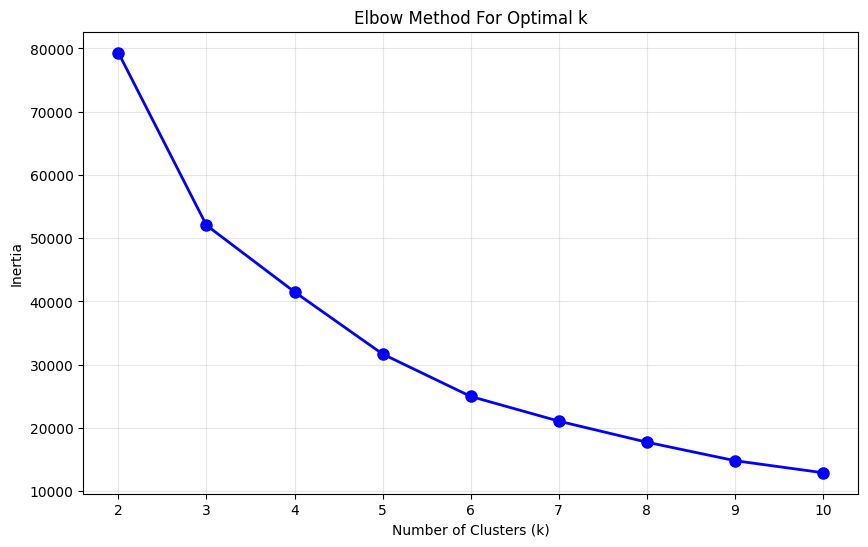


Look for the 'elbow' point where the decrease slows down.


In [8]:
# ============================================
# Step 5: Elbow Method - Find Optimal k
# ============================================

from sklearn.cluster import KMeans

print("="*50)
print("Step 4: Finding Optimal Number of Clusters")
print("="*50)

inertias = []
K_range = range(2, 11)

for k in K_range:
    print(f"Testing k={k}...", end=" ", flush=True)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(umap_embeddings)
    inertias.append(kmeans.inertia_)
    print(f"inertia={kmeans.inertia_:.0f}")

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True, alpha=0.3)
plt.show()

print("\nLook for the 'elbow' point where the decrease slows down.")

In [9]:
# ============================================
# Step 6: K-Means Clustering
# ============================================

# Choose optimal k (based on elbow plot, typically 4-6)
n_clusters = 6  # Adjust based on your elbow plot

print("="*50)
print(f"Step 5: K-Means Clustering (k={n_clusters})")
print("="*50)

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
target_df_raw['cluster'] = kmeans.fit_predict(umap_embeddings)

print(f"✅ Clustering complete")
print("\nCluster distribution:")
print(target_df_raw['cluster'].value_counts().sort_index())

Step 5: K-Means Clustering (k=6)
✅ Clustering complete

Cluster distribution:
cluster
0    2116
1    2189
2    1871
3      72
4    2304
5    1448
Name: count, dtype: int64


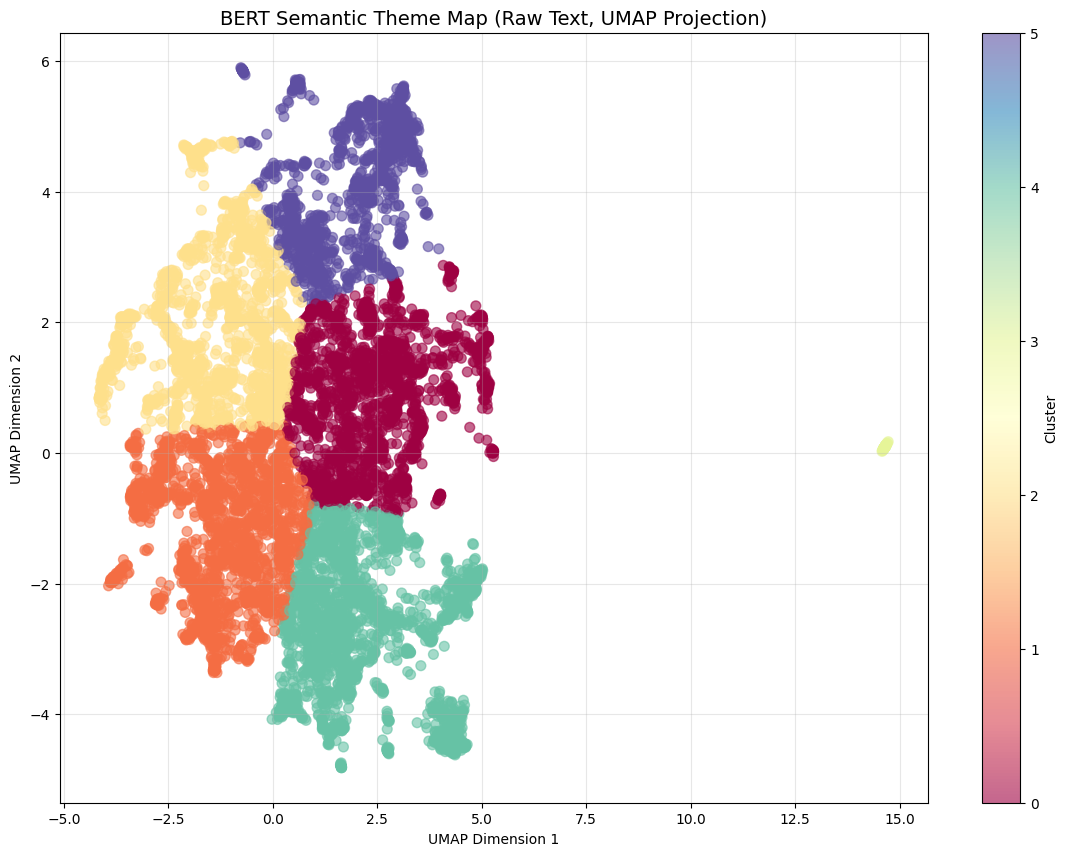

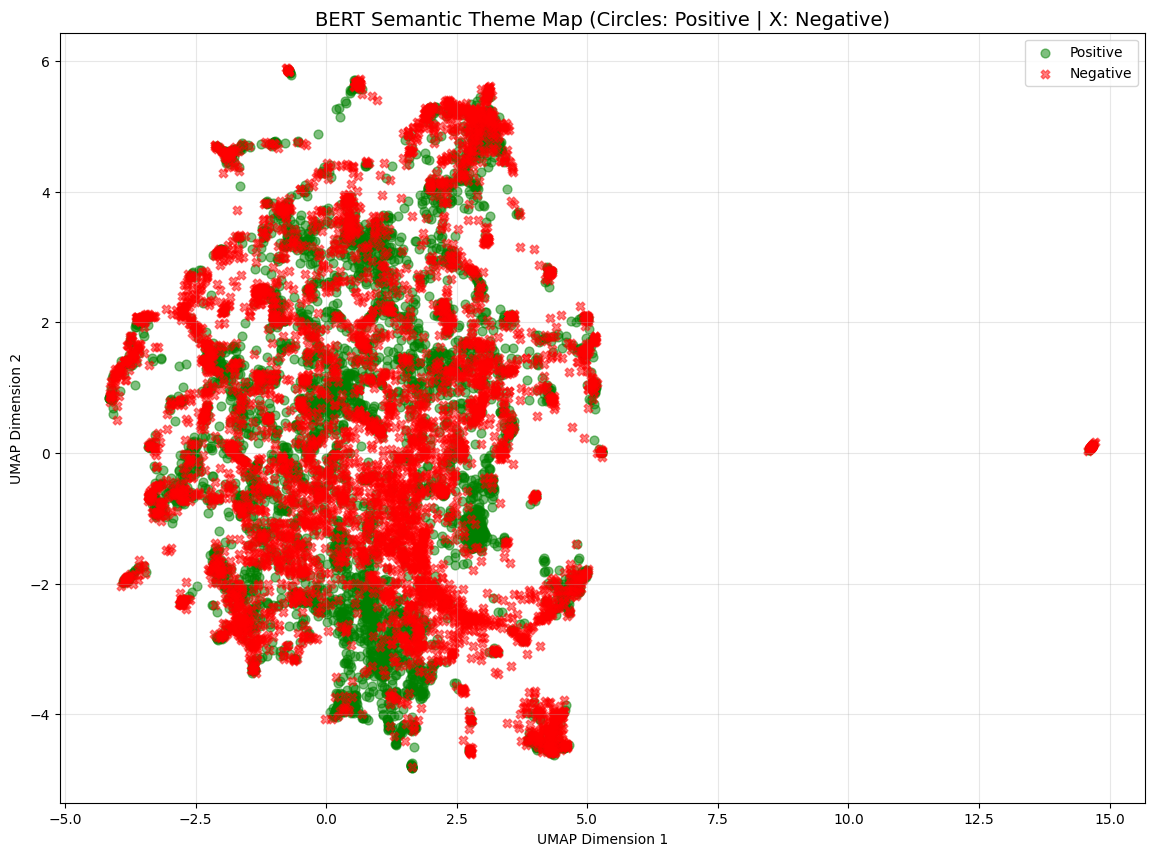

In [10]:
# ============================================
# Step 7: Semantic Theme Map Visualization
# ============================================

import seaborn as sns

# Create sentiment group for markers
target_df_raw['sentiment_group'] = target_df_raw['rating'].apply(
    lambda x: 'Positive' if x >= 4 else 'Negative'
)

plt.figure(figsize=(14, 10))

# Scatter plot with UMAP coordinates
scatter = plt.scatter(
    umap_embeddings[:, 0],
    umap_embeddings[:, 1],
    c=target_df_raw['cluster'],
    cmap='Spectral',
    alpha=0.6,
    s=50
)

plt.colorbar(scatter, label='Cluster')
plt.title('BERT Semantic Theme Map (Raw Text, UMAP Projection)', fontsize=14)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()

# Separate plot with sentiment markers
plt.figure(figsize=(14, 10))

markers = {'Positive': 'o', 'Negative': 'X'}
colors = {'Positive': 'green', 'Negative': 'red'}

for sentiment in ['Positive', 'Negative']:
    mask = target_df_raw['sentiment_group'] == sentiment
    plt.scatter(
        umap_embeddings[mask, 0],
        umap_embeddings[mask, 1],
        c=colors[sentiment],
        marker=markers[sentiment],
        label=sentiment,
        alpha=0.5,
        s=40
    )

plt.legend()
plt.title('BERT Semantic Theme Map (Circles: Positive | X: Negative)', fontsize=14)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# ============================================
# Extended Stop Words for Better Clustering
# ============================================

stop_words = {
    # Basic English stop words
    'the', 'a', 'an', 'and', 'or', 'but', 'so', 'for', 'of', 'to', 'in',
    'on', 'at', 'by', 'with', 'without', 'is', 'are', 'was', 'were',
    'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does',
    'did', 'doing', 'this', 'that', 'these', 'those', 'it', 'they',
    'them', 'their', 'we', 'you', 'he', 'she', 'it', 'i', 'my', 'me',
    'would', 'could', 'should', 'will', 'can', 'may', 'might', 'very',
    'just', 'get', 'got', 'make', 'made', 'use', 'used', 'one', 'two',
    'three', 'first', 'also', 'even',

    # Generic sentiment words (appear in almost all reviews)
    'great', 'good', 'like', 'love', 'really', 'nice', 'awesome', 'perfect',
    'excellent', 'amazing', 'wonderful', 'fantastic', 'beautiful',

    # Generic product/transaction words
    'product', 'item', 'bought', 'purchase', 'purchased', 'order', 'ordered',
    'amazon', 'seller', 'store', 'website', 'shopping', 'buy', 'bought',

    # Common adverbs and prepositions
    'when', 'after', 'before', 'from', 'your', 'our', 'their', 'than', 'then',
    'there', 'their', 'about', 'which', 'what', 'where', 'here', 'there',
    'just', 'only', 'also', 'very', 'really', 'quite', 'pretty',

    # Contractions
    'it\'s', 'that\'s', 'there\'s', 'what\'s', 'don\'t', 'doesn\'t', 'didn\'t',
    'wasn\'t', 'weren\'t', 'isn\'t', 'aren\'t', 'can\'t', 'couldn\'t',
    'wouldn\'t', 'shouldn\'t', 'won\'t', 'i\'m', 'you\'re', 'he\'s', 'she\'s',
    'we\'re', 'they\'re',

    # Short words (less than 4 characters, excluding meaningful ones)
    'two', 'get', 'use', 'buy', 'new', 'old', 'big', 'small', 'high', 'low',
    'bad', 'sad', 'mad', 'red', 'blue', 'black', 'white', 'green',

    # Additional common words from your output
    'these', 'those', 'such', 'each', 'every', 'both', 'same', 'different',
    'back', 'well', 'still', 'even', 'though', 'although', 'however',
    'because', 'since', 'while', 'during', 'within', 'without', 'through',
    'between', 'among', 'under', 'over', 'after', 'before', 'above', 'below'
}

print(f"Total stop words: {len(stop_words)}")

Total stop words: 170


In [12]:
# ============================================
# Extract Keywords with Extended Stop Words
# ============================================

from collections import Counter

print("="*60)
print("RQ2: BERT SEMANTIC CLUSTERING (k=6) - WITH ENHANCED FILTERING")
print("="*60)

# Ensure clustering is done (k=6)
n_clusters = 6
if 'cluster' not in target_df_raw.columns or target_df_raw['cluster'].nunique() != n_clusters:
    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    target_df_raw['cluster'] = kmeans.fit_predict(umap_embeddings)

print("\nCluster distribution:")
print(target_df_raw['cluster'].value_counts().sort_index())

for i in range(n_clusters):
    cluster_subset = target_df_raw[target_df_raw['cluster'] == i]

    if len(cluster_subset) == 0:
        print(f"\nCluster {i}: Empty")
        continue

    # Sentiment breakdown
    pos_count = (cluster_subset['rating'] >= 4).sum()
    neg_count = (cluster_subset['rating'] <= 2).sum()
    neutral_count = len(cluster_subset) - pos_count - neg_count
    pos_rate = pos_count / len(cluster_subset)
    neg_rate = neg_count / len(cluster_subset)

    # Extract top keywords
    all_text = " ".join(cluster_subset['text_clean'].astype(str))
    words = all_text.lower().split()
    word_counts = Counter(words)

    # Filter with extended stop words
    filtered_words = [(w, c) for w, c in word_counts.most_common(200)
                      if w not in stop_words and len(w) > 3]
    top_keywords = [w for w, c in filtered_words[:12]]

    # Business insight label
    if pos_rate > 0.65:
        label = "🟢 CORE STRENGTH / SELLING POINT"
    elif neg_rate > 0.65:
        label = "🔴 CRITICAL PAIN POINT"
    else:
        label = "🟡 MIXED FEEDBACK / NEUTRAL"

    print(f"\n{'='*50}")
    print(f"CLUSTER {i} ({len(cluster_subset)} reviews)")
    print(f"{'='*50}")
    print(f"Sentiment: Positive {pos_rate:.1%} | Neutral {neutral_count/len(cluster_subset):.1%} | Negative {neg_rate:.1%}")
    print(f"Top Keywords: {', '.join(top_keywords[:10])}")
    print(f"Insight: {label}")

RQ2: BERT SEMANTIC CLUSTERING (k=6) - WITH ENHANCED FILTERING

Cluster distribution:
cluster
0    2116
1    2189
2    1871
3      72
4    2304
5    1448
Name: count, dtype: int64

CLUSTER 0 (2116 reviews)
Sentiment: Positive 47.7% | Neutral 0.0% | Negative 52.3%
Top Keywords: size, more, fits, quality, comfortable, time, other, wear, much, look
Insight: 🟡 MIXED FEEDBACK / NEUTRAL

CLUSTER 1 (2189 reviews)
Sentiment: Positive 49.5% | Neutral 0.0% | Negative 50.5%
Top Keywords: easy, bike, more, other, little, time, much, some, quality, works
Insight: 🟡 MIXED FEEDBACK / NEUTRAL

CLUSTER 2 (1871 reviews)
Sentiment: Positive 51.4% | Neutral 0.0% | Negative 48.6%
Top Keywords: more, easy, ball, time, using, other, much, work, little, tent
Insight: 🟡 MIXED FEEDBACK / NEUTRAL

CLUSTER 3 (72 reviews)
Sentiment: Positive 51.4% | Neutral 0.0% | Negative 48.6%
Top Keywords: para, calidad, llego, buena, producto, buen, como, pero, material, excelente
Insight: 🟡 MIXED FEEDBACK / NEUTRAL

CLUSTER 4 

# Exploration Process Summary

Initial attempts used mixed clustering (positive and negative reviews together) with k=3 to k=6. However, all clusters showed approximately 50% positive and 50% negative sentiment, making it impossible to distinguish selling points from pain points.

After filtering 410 non-English reviews, the issue persisted.

The final approach separated positive reviews (4-5 stars) and negative reviews (1-2 stars) before clustering. This successfully revealed three distinct selling points from positive reviews and three distinct pain points from negative reviews.

In [13]:
# Remove or separate Spanish reviews
spanish_keywords = ['para', 'calidad', 'llego', 'buena', 'producto', 'buen', 'como', 'pero', 'material', 'excelente']
mask_spanish = target_df_raw['text_clean'].str.contains('|'.join(spanish_keywords), na=False)
target_df_english = target_df_raw[~mask_spanish].copy()
print(f"Removed {mask_spanish.sum()} Spanish reviews")
print(f"Remaining: {len(target_df_english)} reviews")

Removed 410 Spanish reviews
Remaining: 9590 reviews


In [14]:
# ==============================================================================
# FILTER EXISTING EMBEDDINGS (No re-generation needed)
# ==============================================================================

import numpy as np

# Get the mask for Spanish reviews (from earlier)
mask_spanish = target_df_raw['text_clean'].str.contains('|'.join(spanish_keywords), na=False)

# Filter the existing embeddings and UMAP results
embeddings_filtered = embeddings[~mask_spanish.values]
umap_embeddings_filtered = umap_embeddings[~mask_spanish.values]

# Filter the dataframe
target_df = target_df_raw[~mask_spanish].copy()

print(f"Original: {len(target_df_raw)} reviews")
print(f"Filtered: {len(target_df)} reviews (removed {mask_spanish.sum()} Spanish reviews)")
print(f"Embeddings shape: {embeddings_filtered.shape}")

# Now run clustering on the filtered data
from sklearn.cluster import KMeans

n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
target_df['cluster'] = kmeans.fit_predict(umap_embeddings_filtered)

print(f"\n✅ Clustered {len(target_df)} reviews into {n_clusters} themes")
print("\nCluster distribution:")
print(target_df['cluster'].value_counts().sort_index())

Original: 10000 reviews
Filtered: 9590 reviews (removed 410 Spanish reviews)
Embeddings shape: (9590, 384)

✅ Clustered 9590 reviews into 6 themes

Cluster distribution:
cluster
0    1902
1     688
2    1848
3    1997
4    1777
5    1378
Name: count, dtype: int64


In [15]:
# ==============================================================================
# SEPARATE CLUSTERING: Positive vs Negative Reviews
# ==============================================================================

from sklearn.cluster import KMeans
from collections import Counter

# Split data
positive_df = target_df[target_df['rating'] >= 4].copy()
negative_df = target_df[target_df['rating'] <= 2].copy()

print(f"Positive reviews: {len(positive_df)}")
print(f"Negative reviews: {len(negative_df)}")

# Get embeddings for positive and negative separately
# (Assuming embeddings_filtered is aligned with target_df)
positive_mask = target_df['rating'] >= 4
negative_mask = target_df['rating'] <= 2

positive_embeddings = embeddings_filtered[positive_mask]
negative_embeddings = embeddings_filtered[negative_mask]

print(f"Positive embeddings: {positive_embeddings.shape}")
print(f"Negative embeddings: {negative_embeddings.shape}")

# Cluster positive reviews (k=3)
kmeans_pos = KMeans(n_clusters=3, random_state=42, n_init=10)
positive_df['cluster'] = kmeans_pos.fit_predict(positive_embeddings)

# Cluster negative reviews (k=3)
kmeans_neg = KMeans(n_clusters=3, random_state=42, n_init=10)
negative_df['cluster'] = kmeans_neg.fit_predict(negative_embeddings)

print("\n✅ Positive clusters distribution:")
print(positive_df['cluster'].value_counts().sort_index())

print("\n✅ Negative clusters distribution:")
print(negative_df['cluster'].value_counts().sort_index())

Positive reviews: 4818
Negative reviews: 4772
Positive embeddings: (4818, 384)
Negative embeddings: (4772, 384)

✅ Positive clusters distribution:
cluster
0    1724
1    1466
2    1628
Name: count, dtype: int64

✅ Negative clusters distribution:
cluster
0    1679
1    2267
2     826
Name: count, dtype: int64


In [16]:
# Quick check to ensure alignment
print(f"embeddings shape: {embeddings.shape}")
print(f"mask_spanish sum: {mask_spanish.sum()}")
print(f"embeddings_filtered shape: {embeddings_filtered.shape}")
print(f"Expected: {len(target_df_raw) - mask_spanish.sum()}")

# Should match
assert embeddings_filtered.shape[0] == len(target_df)
print("✅ Index alignment verified")

embeddings shape: (10000, 384)
mask_spanish sum: 410
embeddings_filtered shape: (9590, 384)
Expected: 9590
✅ Index alignment verified


In [17]:
# ==============================================================================
# EXTRACT KEYWORDS AND MARKETING INSIGHTS (k=6, English-only)
# ==============================================================================

from collections import Counter

# Ensure sentiment_group exists
target_df['sentiment_group'] = target_df['rating'].apply(
    lambda x: 'Positive' if x >= 4 else 'Negative'
)

# Extended stop words
extended_stops = {
    'the', 'a', 'an', 'and', 'or', 'but', 'so', 'for', 'of', 'to', 'in',
    'on', 'at', 'by', 'with', 'without', 'is', 'are', 'was', 'were',
    'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does',
    'did', 'doing', 'this', 'that', 'these', 'those', 'it', 'they',
    'them', 'their', 'we', 'you', 'he', 'she', 'we', 'our', 'his', 'her',
    'great', 'good', 'like', 'love', 'really', 'nice', 'awesome', 'perfect',
    'excellent', 'amazing', 'wonderful', 'fantastic', 'product', 'item',
    'bought', 'purchase', 'purchased', 'order', 'ordered', 'amazon', 'seller',
    'when', 'after', 'before', 'from', 'your', 'than', 'then', 'there',
    'about', 'which', 'what', 'where', 'here', 'just', 'only', 'also', 'very',
    'would', 'could', 'should', 'will', 'can', 'may', 'might', 'get', 'got',
    'make', 'made', 'use', 'used', 'using', 'work', 'works', 'keep', 'come',
    'came', 'time', 'day', 'week', 'month', 'year', 'more', 'much', 'some',
    'other', 'little', 'easy', 'it\'s', 'that\'s', 'don\'t', 'doesn\'t', 'didn\'t'
}

print("="*60)
print("RQ2: MARKETING INSIGHTS FROM BERT SEMANTIC CLUSTERING (k=6)")
print("="*60)

results_summary = []

for i in range(6):
    cluster_data = target_df[target_df['cluster'] == i]

    if len(cluster_data) == 0:
        print(f"\n[Cluster {i}] - EMPTY")
        continue

    # Sentiment breakdown
    pos_count = (cluster_data['rating'] >= 4).sum()
    neg_count = (cluster_data['rating'] <= 2).sum()
    pos_rate = pos_count / len(cluster_data)
    neg_rate = neg_count / len(cluster_data)

    # Extract keywords
    all_words = " ".join(cluster_data['text_clean'].astype(str))
    words = all_words.lower().split()
    word_counts = Counter(words)

    filtered_words = [(w, c) for w, c in word_counts.most_common(200)
                      if w not in extended_stops and len(w) > 4]
    top_keywords = [w for w, c in filtered_words[:12]]

    # Business insight label
    if neg_rate > 0.60:
        label = "🔴 CRITICAL PAIN POINT"
        priority = "HIGH - Address Immediately"
    elif pos_rate > 0.60:
        label = "🟢 CORE STRENGTH / SELLING POINT"
        priority = "HIGH - Leverage in Marketing"
    else:
        label = "🟡 MIXED FEEDBACK"
        priority = "MEDIUM - Investigate Further"

    print(f"\n{'='*50}")
    print(f"CLUSTER {i} ({len(cluster_data)} reviews)")
    print(f"{'='*50}")
    print(f"Positive: {pos_rate:.1%} | Negative: {neg_rate:.1%}")
    print(f"Top Keywords: {', '.join(top_keywords)}")
    print(f"Insight: {label}")
    print(f"Priority: {priority}")

    results_summary.append({
        'cluster': i,
        'size': len(cluster_data),
        'positive_ratio': pos_rate,
        'negative_ratio': neg_rate,
        'top_keywords': ', '.join(top_keywords[:8]),
        'insight': label
    })

# Save summary
summary_df = pd.DataFrame(results_summary)
summary_df.to_csv('bert_clustering_marketing_insights.csv', index=False)
print("\n" + "="*60)
print("✅ Marketing insights saved to: bert_clustering_marketing_insights.csv")
print("="*60)
print("\nSummary Table:")
print(summary_df.to_string(index=False))

RQ2: MARKETING INSIGHTS FROM BERT SEMANTIC CLUSTERING (k=6)

CLUSTER 0 (1902 reviews)
Positive: 51.9% | Negative: 48.1%
Top Keywords: because, first, quality, small, recommend, while, balls, still, better, enough, broke, thing
Insight: 🟡 MIXED FEEDBACK
Priority: MEDIUM - Investigate Further

CLUSTER 1 (688 reviews)
Positive: 32.6% | Negative: 67.4%
Top Keywords: light, battery, fitbit, charge, watch, because, heart, first, tried, steps, bright, worked
Insight: 🔴 CRITICAL PAIN POINT
Priority: HIGH - Address Immediately

CLUSTER 2 (1848 reviews)
Positive: 50.1% | Negative: 49.9%
Top Keywords: small, quality, first, comfortable, because, received, bands, recommend, looks, them., while, color
Insight: 🟡 MIXED FEEDBACK
Priority: MEDIUM - Investigate Further

CLUSTER 3 (1997 reviews)
Positive: 55.5% | Negative: 44.5%
Top Keywords: quality, broke, first, price, looks, exactly, loved, arrived, loves, worth, cheap, money
Insight: 🟡 MIXED FEEDBACK
Priority: MEDIUM - Investigate Further

CLUSTER 

In [18]:
print("\n" + "="*60)
print("PAIN POINTS (Negative Reviews Clusters)")
print("="*60)

for i in range(3):
    cluster_data = negative_df[negative_df['cluster'] == i]
    all_words = " ".join(cluster_data['text_clean'].astype(str))
    words = all_words.lower().split()
    word_counts = Counter(words)

    filtered_words = [(w, c) for w, c in word_counts.most_common(100)
                      if w not in extended_stops and len(w) > 4]
    top_keywords = [w for w, c in filtered_words[:10]]

    print(f"\nCluster {i} ({len(cluster_data)} reviews): {', '.join(top_keywords)}")


PAIN POINTS (Negative Reviews Clusters)

Cluster 0 (1679 reviews): small, because, first, quality, better, received

Cluster 1 (2267 reviews): broke, first, because, return, light, waste, money

Cluster 2 (826 reviews): water, bottle, first, because, leaks, inside, return, tried


In [19]:
print("\n" + "="*60)
print("SELLING POINTS (Positive Reviews Clusters)")
print("="*60)

for i in range(3):
    cluster_data = positive_df[positive_df['cluster'] == i]
    all_words = " ".join(cluster_data['text_clean'].astype(str))
    words = all_words.lower().split()
    word_counts = Counter(words)

    filtered_words = [(w, c) for w, c in word_counts.most_common(100)
                      if w not in extended_stops and len(w) > 4]
    top_keywords = [w for w, c in filtered_words[:10]]

    print(f"\nCluster {i} ({len(cluster_data)} reviews): {', '.join(top_keywords)}")


SELLING POINTS (Positive Reviews Clusters)

Cluster 0 (1724 reviews): light, quality

Cluster 1 (1466 reviews): quality, loves, loved, looks, price, happy, price., recommend, super, definitely

Cluster 2 (1628 reviews): water, comfortable, recommend, enough, because, bottle


Positive UMAP shape: (4818, 2)
Negative UMAP shape: (4772, 2)


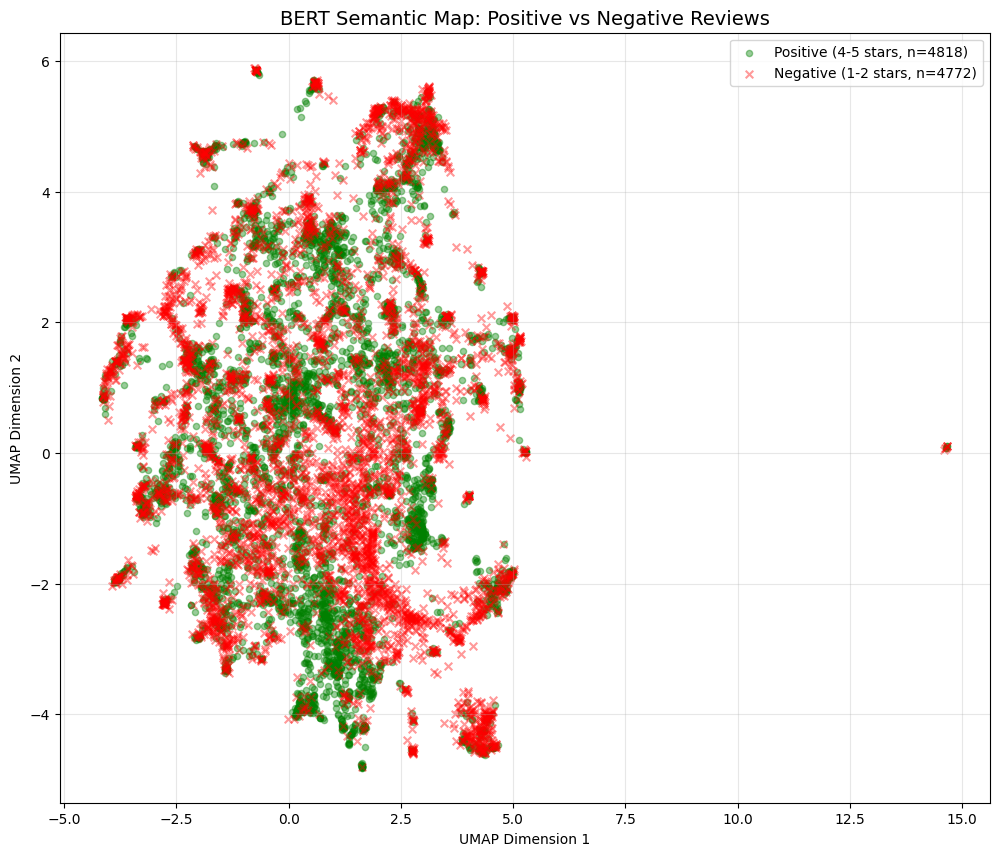

In [20]:
# ==============================================================================
# UMAP Visualization: Positive vs Negative Reviews
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np

# Get UMAP coordinates for positive and negative reviews
# Assuming:
#   umap_embeddings_filtered: UMAP results for all 9590 English reviews
#   positive_mask: boolean mask for positive reviews (rating >= 4)
#   negative_mask: boolean mask for negative reviews (rating <= 2)

positive_umap = umap_embeddings_filtered[positive_mask]
negative_umap = umap_embeddings_filtered[negative_mask]

print(f"Positive UMAP shape: {positive_umap.shape}")
print(f"Negative UMAP shape: {negative_umap.shape}")

plt.figure(figsize=(12, 10))

# Plot positive reviews (green circles)
plt.scatter(
    positive_umap[:, 0],
    positive_umap[:, 1],
    c='green',
    marker='o',
    label=f'Positive (4-5 stars, n={len(positive_umap)})',
    alpha=0.4,
    s=20
)

# Plot negative reviews (red X's)
plt.scatter(
    negative_umap[:, 0],
    negative_umap[:, 1],
    c='red',
    marker='x',
    label=f'Negative (1-2 stars, n={len(negative_umap)})',
    alpha=0.4,
    s=30
)

plt.title('BERT Semantic Map: Positive vs Negative Reviews', fontsize=14)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

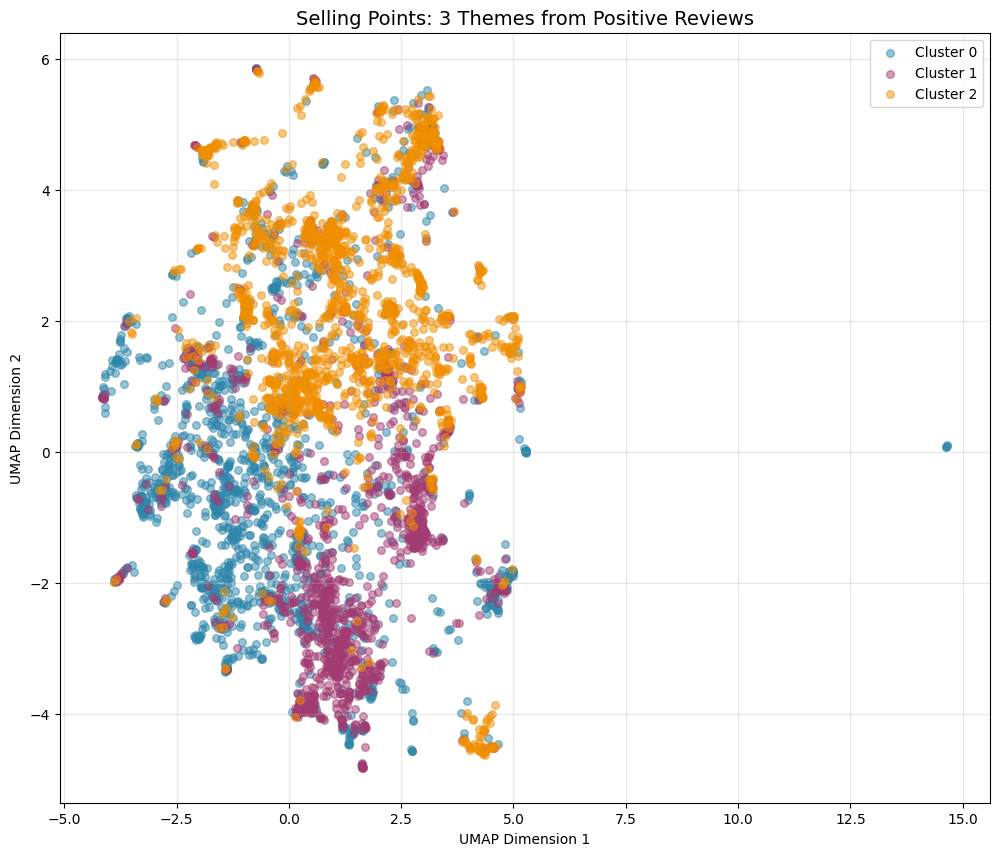

In [26]:
# ==============================================================================
# UMAP Visualization: Positive Clusters (Selling Points)
# ==============================================================================

# Get UMAP coordinates for positive reviews only
positive_umap = umap_embeddings_filtered[positive_mask]

plt.figure(figsize=(12, 10))

colors = ['#2E86AB', '#A23B72', '#F18F01']  # 3 distinct colors

for i in range(3):
    cluster_mask = positive_df['cluster'] == i
    plt.scatter(
        positive_umap[cluster_mask, 0],
        positive_umap[cluster_mask, 1],
        c=colors[i],
        label=f'Cluster {i}',
        alpha=0.5,
        s=30
    )

plt.title('Selling Points: 3 Themes from Positive Reviews', fontsize=14)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('selling_points_umap.png', dpi=300, bbox_inches='tight')
plt.show()
plt.show()

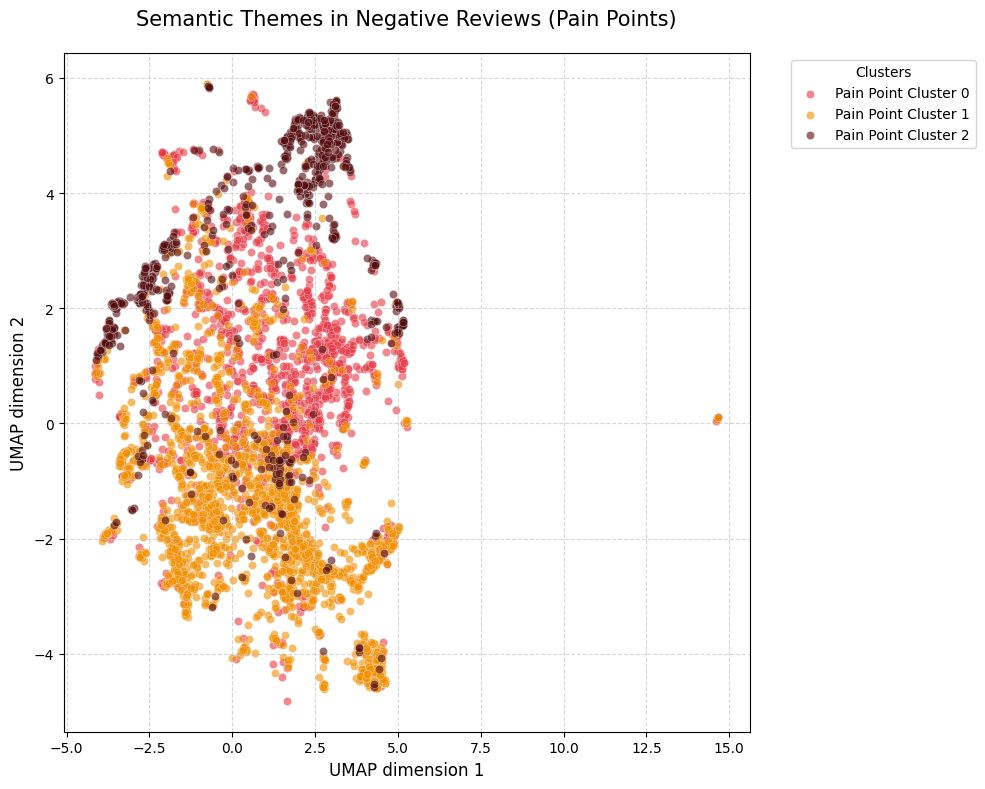

In [27]:
# ==============================================================================
# UMAP Visualization: Negative Clusters (Pain Points)
# ==============================================================================

# 1. Extract UMAP coordinates for negative reviews
# Ensure negative_mask is defined from your sentiment filtering step
negative_umap = umap_embeddings_filtered[negative_mask]

plt.figure(figsize=(10, 8))

# Professional Color Palette for Pain Points (Muted Red, Earthy Brown, Slate Gray)
# These colors look more sophisticated in presentations than standard 'red', 'blue', 'green'
pain_point_colors = ['#E63946', '#F18F01', '#540B0E']

for i in range(3):
    # Ensure negative_df contains your clustering results for negative reviews
    cluster_mask = negative_df['cluster'] == i
    plt.scatter(
        negative_umap[cluster_mask, 0],
        negative_umap[cluster_mask, 1],
        c=pain_point_colors[i],
        label=f'Pain Point Cluster {i}',
        alpha=0.6,    # Slight transparency for better overlap visibility
        s=35,         # Point size
        edgecolors='white', # White edge for better contrast
        linewidths=0.3
    )

# Formatting the plot
plt.title('Semantic Themes in Negative Reviews (Pain Points)', fontsize=15, pad=20)
plt.xlabel('UMAP dimension 1', fontsize=12)
plt.ylabel('UMAP dimension 2', fontsize=12)

# Legend placement: outside the plot area often looks cleaner
plt.legend(title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save for your presentation
plt.savefig('negative_umap_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

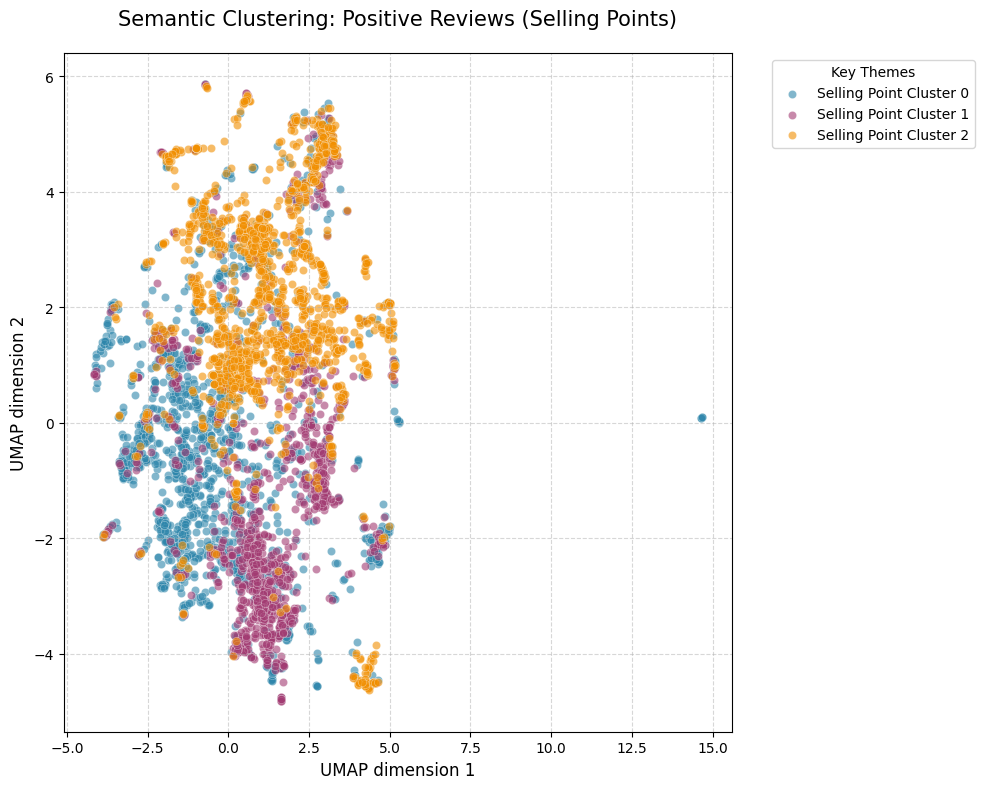

Success: 'selling_points_umap.png' has been saved.


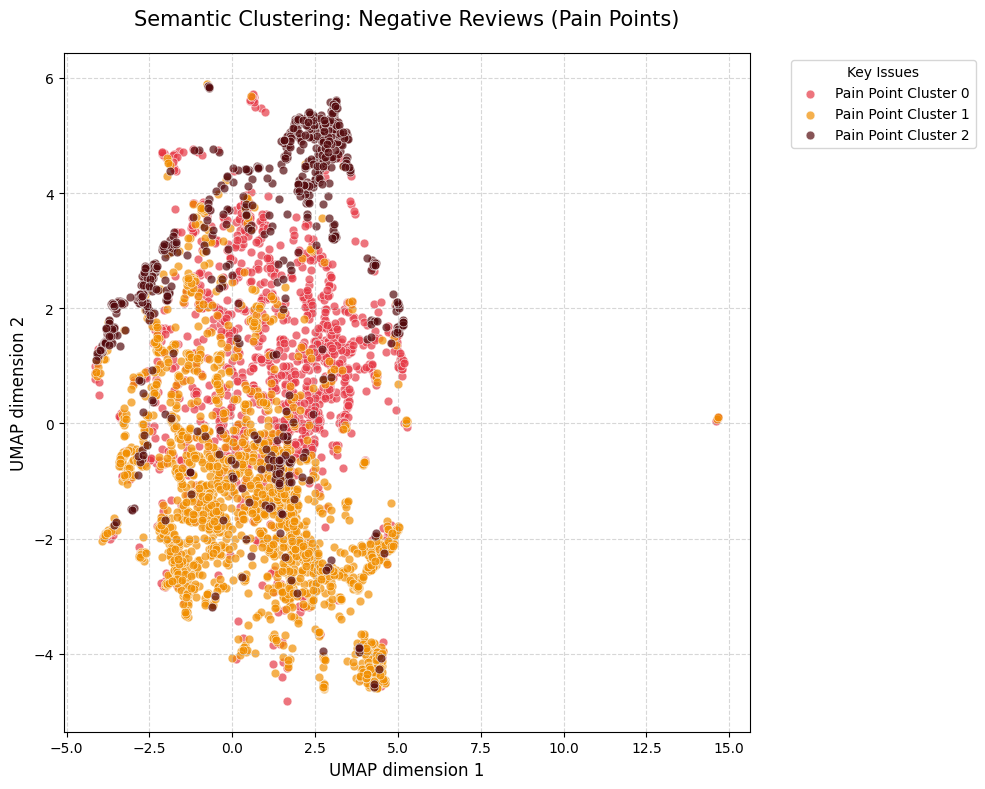

Success: 'pain_points_umap.png' has been saved.


In [28]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# VISUALIZATION 1: Positive Reviews (Selling Points)
# ==============================================================================
# Extract coordinates for positive sentiment cluster
positive_umap = umap_embeddings_filtered[positive_mask]

plt.figure(figsize=(10, 8))

# Professional Palette: Cyan, Magenta, Golden Orange
pos_colors = ['#2E86AB', '#A23B72', '#F18F01']

for i in range(3):
    cluster_mask = positive_df['cluster'] == i
    plt.scatter(
        positive_umap[cluster_mask, 0],
        positive_umap[cluster_mask, 1],
        c=pos_colors[i],
        label=f'Selling Point Cluster {i}',
        alpha=0.6,
        s=35,
        edgecolors='white',
        linewidths=0.3
    )

plt.title('Semantic Clustering: Positive Reviews (Selling Points)', fontsize=15, pad=20)
plt.xlabel('UMAP dimension 1', fontsize=12)
plt.ylabel('UMAP dimension 2', fontsize=12)
plt.legend(title="Key Themes", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save for PPT
plt.savefig('selling_points_umap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Success: 'selling_points_umap.png' has been saved.")


# ==============================================================================
# VISUALIZATION 2: Negative Reviews (Pain Points)
# ==============================================================================
# Extract coordinates for negative sentiment cluster
negative_umap = umap_embeddings_filtered[negative_mask]

plt.figure(figsize=(10, 8))

# High-Contrast Alert Palette: Crimson, Amber, Deep Maroon
neg_colors = ['#E63946', '#F18F01', '#540B0E']

for i in range(3):
    cluster_mask = negative_df['cluster'] == i
    plt.scatter(
        negative_umap[cluster_mask, 0],
        negative_umap[cluster_mask, 1],
        c=neg_colors[i],
        label=f'Pain Point Cluster {i}',
        alpha=0.7,
        s=40,
        edgecolors='white',
        linewidths=0.5
    )

plt.title('Semantic Clustering: Negative Reviews (Pain Points)', fontsize=15, pad=20)
plt.xlabel('UMAP dimension 1', fontsize=12)
plt.ylabel('UMAP dimension 2', fontsize=12)
plt.legend(title="Key Issues", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save for PPT
plt.savefig('pain_points_umap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Success: 'pain_points_umap.png' has been saved.")

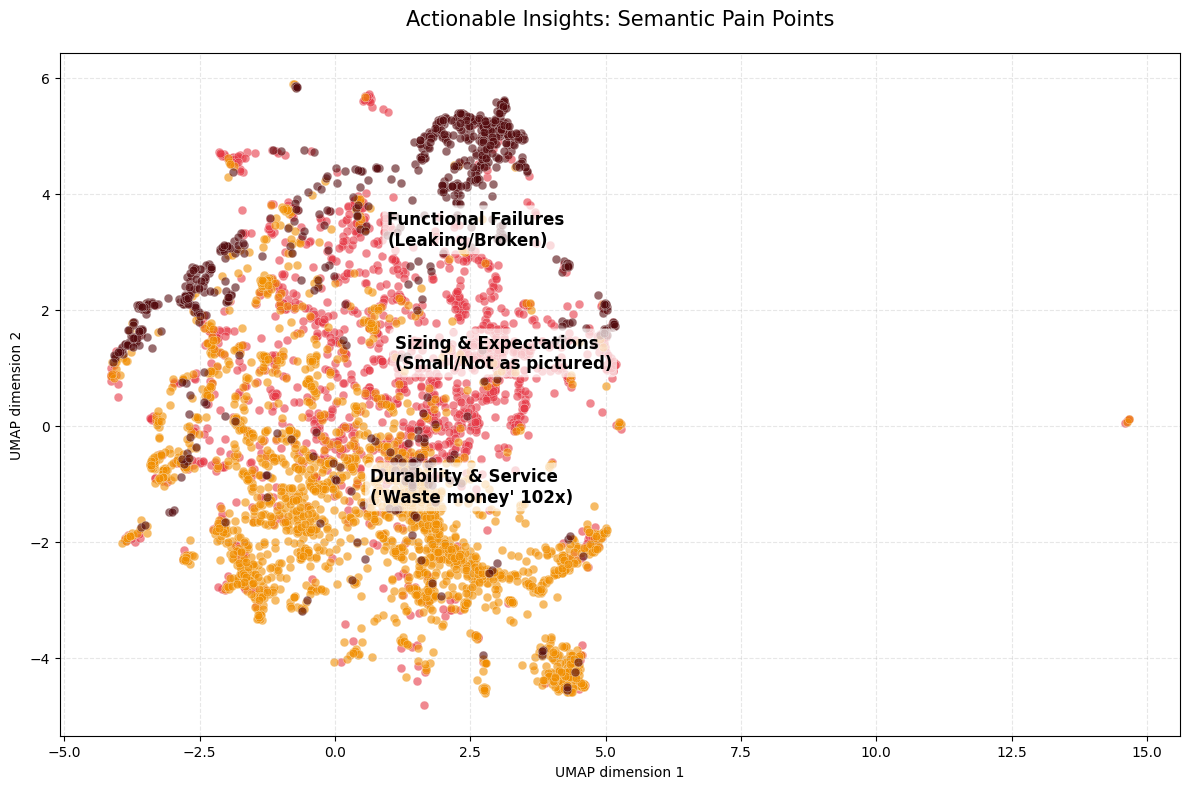

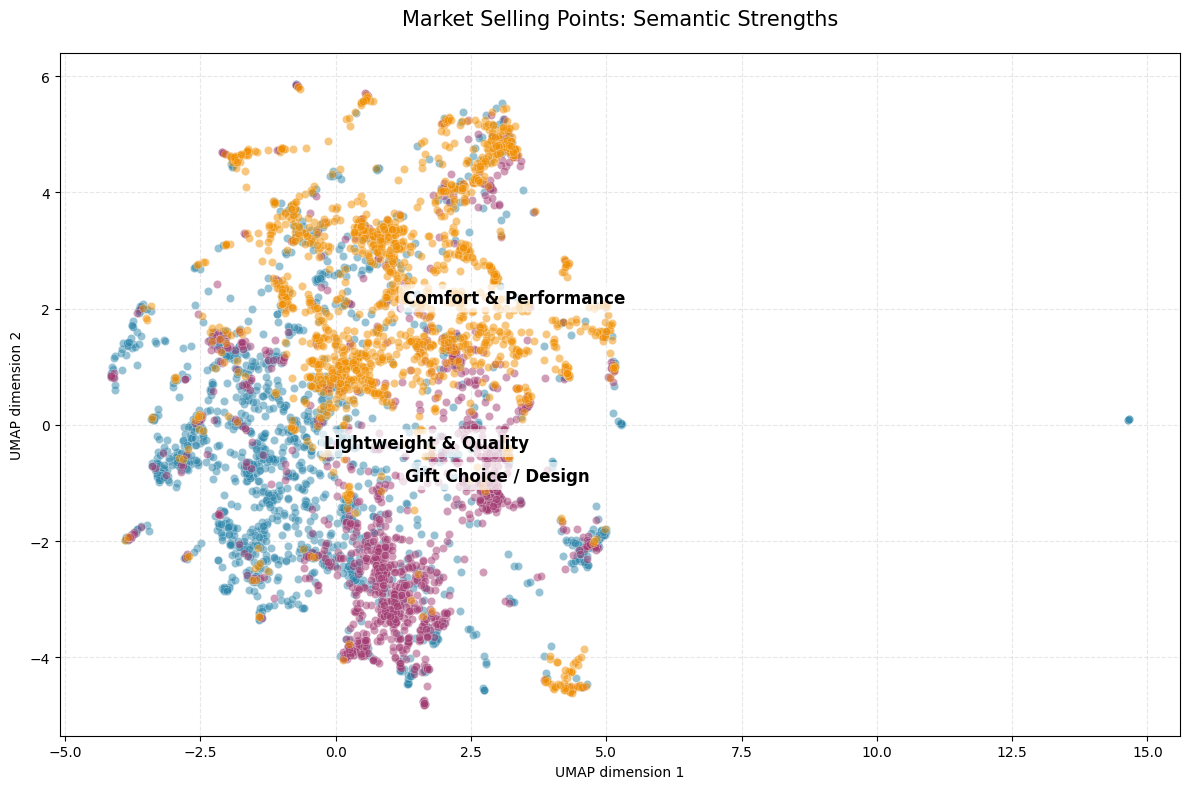

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. 负面评论图：直接在图上标注关键词 (Pain Points)
# ==============================================================================
negative_umap = umap_embeddings_filtered[negative_mask]
plt.figure(figsize=(12, 8))

neg_colors = ['#E63946', '#F18F01', '#540B0E']

# 根据你的 PPT 结论定义关键词
neg_labels = {
    0: "Sizing & Expectations\n(Small/Not as pictured)",
    1: "Durability & Service\n('Waste money' 102x)",
    2: "Functional Failures\n(Leaking/Broken)"
}

for i in range(3):
    mask = negative_df['cluster'] == i
    points = negative_umap[mask]

    # 画散点
    plt.scatter(points[:, 0], points[:, 1], c=neg_colors[i], alpha=0.6, s=40, edgecolors='white', linewidths=0.3)

    # 【核心：计算中心点并在图上标注文字】
    center_x, center_y = np.mean(points[:, 0]), np.mean(points[:, 1])
    plt.text(center_x, center_y, neg_labels[i],
             fontsize=12, fontweight='bold', color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

plt.title('Actionable Insights: Semantic Pain Points', fontsize=15, pad=20)
plt.xlabel('UMAP dimension 1')
plt.ylabel('UMAP dimension 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('pain_points_with_labels.png', dpi=300)
plt.show()

# ==============================================================================
# 2. 正面评论图：直接在图上标注关键词 (Selling Points)
# ==============================================================================
positive_umap = umap_embeddings_filtered[positive_mask]
plt.figure(figsize=(12, 8))

pos_colors = ['#2E86AB', '#A23B72', '#F18F01']

pos_labels = {
    0: "Lightweight & Quality",
    1: "Gift Choice / Design",
    2: "Comfort & Performance"
}

for i in range(3):
    mask = positive_df['cluster'] == i
    points = positive_umap[mask]

    plt.scatter(points[:, 0], points[:, 1], c=pos_colors[i], alpha=0.5, s=35, edgecolors='white', linewidths=0.3)

    # 在中心点标注文字
    center_x, center_y = np.mean(points[:, 0]), np.mean(points[:, 1])
    plt.text(center_x, center_y, pos_labels[i],
             fontsize=12, fontweight='bold', color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

plt.title('Market Selling Points: Semantic Strengths', fontsize=15, pad=20)
plt.xlabel('UMAP dimension 1')
plt.ylabel('UMAP dimension 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('selling_points_with_labels.png', dpi=300)
plt.show()

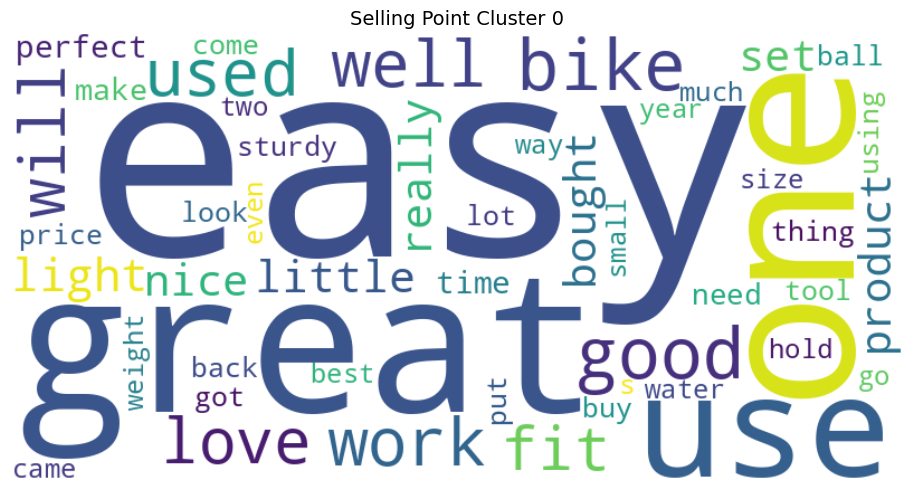

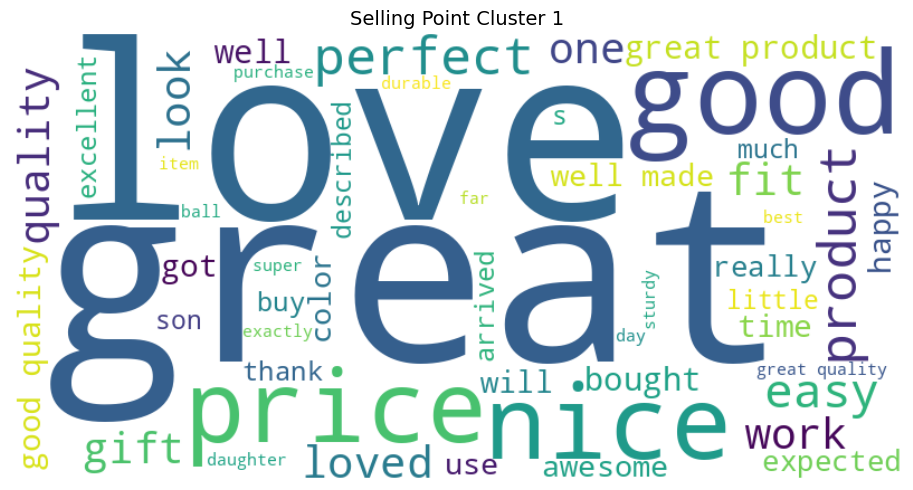

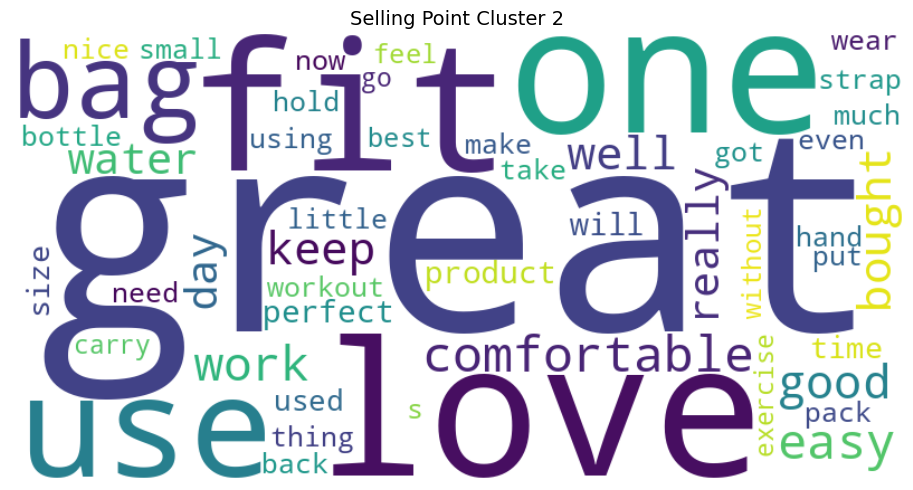

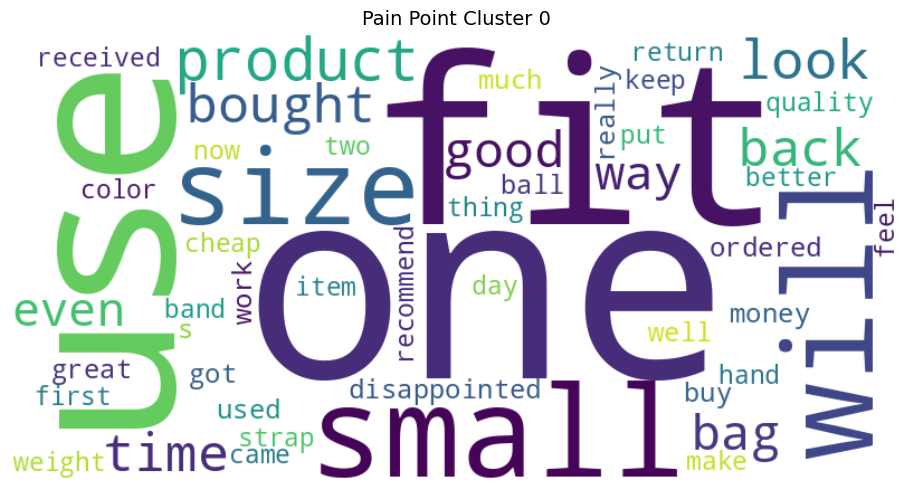

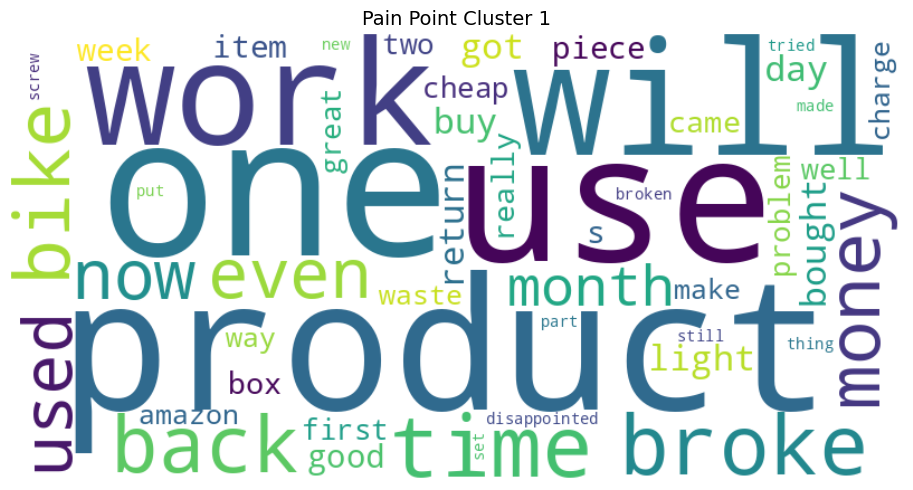

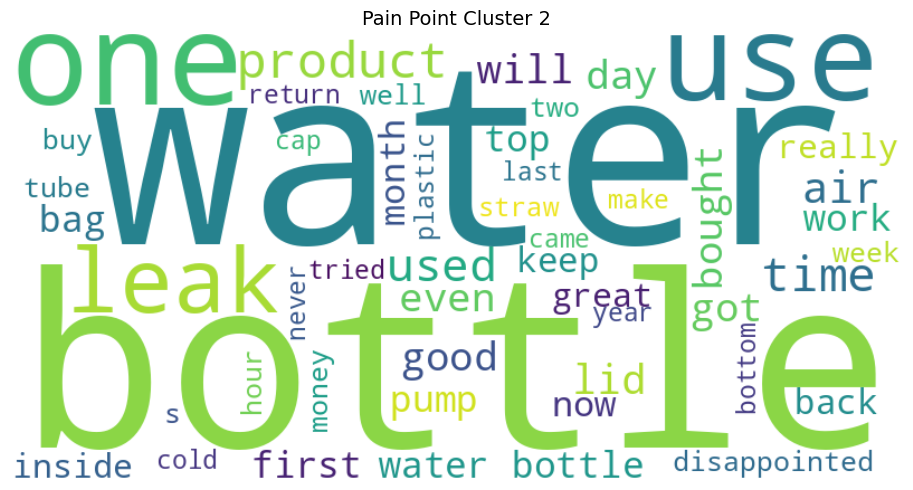

In [ ]:
# ==============================================================================
# Word Clouds for Each Cluster
# ==============================================================================

from wordcloud import WordCloud

# Function to generate word cloud
def generate_wordcloud(texts, title, filename):
    all_text = " ".join(texts.astype(str))
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        max_words=50
    ).generate(all_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

# Generate word clouds for positive clusters
for i in range(3):
    cluster_texts = positive_df[positive_df['cluster'] == i]['text_clean']
    generate_wordcloud(
        cluster_texts,
        f"Selling Point Cluster {i}",
        f"wordcloud_positive_cluster_{i}.png"
    )

# Generate word clouds for negative clusters
for i in range(3):
    cluster_texts = negative_df[negative_df['cluster'] == i]['text_clean']
    generate_wordcloud(
        cluster_texts,
        f"Pain Point Cluster {i}",
        f"wordcloud_negative_cluster_{i}.png"
    )

In [33]:
# ==============================================================================
# EXTENDED STOP WORDS - Filter out generic terms
# ==============================================================================

extended_stops = {
    # Basic English stop words
    'the', 'a', 'an', 'and', 'or', 'but', 'so', 'for', 'of', 'to', 'in',
    'on', 'at', 'by', 'with', 'without', 'is', 'are', 'was', 'were',
    'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does',
    'did', 'doing', 'this', 'that', 'these', 'those', 'it', 'they',
    'them', 'their', 'we', 'you', 'he', 'she', 'we', 'our', 'his', 'her',
    'its', 'your', 'my', 'me', 'him', 'her', 'us', 'our',

    # Generic positive sentiment words (appear everywhere)
    'great', 'good', 'like', 'love', 'really', 'nice', 'awesome', 'perfect',
    'excellent', 'amazing', 'wonderful', 'fantastic', 'beautiful', 'super',
    'happy', 'glad', 'pleased', 'satisfied', 'impressed', 'recommend',
    'recommended', 'recommending', 'definitely', 'absolutely', 'highly',

    # Generic negative sentiment words
    'bad', 'terrible', 'awful', 'horrible', 'disappointed', 'disappointing',

    # Generic product/transaction words
    'product', 'item', 'bought', 'purchase', 'purchased', 'order', 'ordered',
    'amazon', 'seller', 'store', 'shopping', 'buy', 'bought', 'selling',
    'price', 'money', 'cost', 'paid', 'return', 'returned', 'refund',

    # Common verbs (appear everywhere)
    'get', 'got', 'make', 'made', 'use', 'used', 'using', 'work', 'works',
    'worked', 'working', 'keep', 'kept', 'come', 'came', 'go', 'went',
    'going', 'see', 'saw', 'look', 'looked', 'looking', 'seem', 'seemed',
    'need', 'needed', 'want', 'wanted', 'find', 'found', 'give', 'gave',
    'take', 'took', 'put', 'let', 'say', 'said', 'tell', 'told', 'ask', 'asked',

    # Common adverbs and prepositions
    'when', 'after', 'before', 'from', 'than', 'then', 'there', 'their',
    'about', 'which', 'what', 'where', 'here', 'just', 'only', 'also', 'very',
    'quite', 'pretty', 'more', 'much', 'some', 'other', 'little', 'easy',
    'hard', 'better', 'best', 'worse', 'worst', 'less', 'least',

    # Time-related
    'time', 'day', 'days', 'week', 'weeks', 'month', 'months', 'year', 'years',
    'today', 'yesterday', 'tomorrow', 'now', 'then', 'later', 'earlier',

    # Contractions
    'it\'s', 'that\'s', 'there\'s', 'what\'s', 'don\'t', 'doesn\'t', 'didn\'t',
    'wasn\'t', 'weren\'t', 'isn\'t', 'aren\'t', 'can\'t', 'couldn\'t',
    'wouldn\'t', 'shouldn\'t', 'won\'t', 'i\'m', 'you\'re', 'he\'s', 'she\'s',
    'we\'re', 'they\'re', 'i\'ve', 'you\'ve', 'we\'ve', 'they\'ve',

    # Additional from your word clouds
    'first', 'because', 'while', 'still', 'enough', 'looks', 'loves',
    'loved', 'inside', 'tried', 'trying', 'called', 'named', 'known',
    'back', 'well', 'even', 'though', 'although', 'however', 'therefore',
    'also', 'too', 'either', 'neither', 'both', 'each', 'every', 'any',
    'some', 'no', 'none', 'several', 'many', 'lot', 'lots', 'plenty',
    'bit', 'slightly', 'extremely', 'fairly', 'rather', 'somewhat'
}

print(f"Total stop words: {len(extended_stops)}")

Total stop words: 259


In [34]:
# ==============================================================================
# Re-extract Keywords with Enhanced Stop Words
# ==============================================================================

from collections import Counter

positive_keywords_clean = {}
negative_keywords_clean = {}

print("="*60)
print("KEYWORDS BY CLUSTER (After Aggressive Filtering)")
print("="*60)

# Positive clusters
print("\n🟢 SELLING POINTS (Positive Reviews):")
for i in range(3):
    cluster_data = positive_df[positive_df['cluster'] == i]
    all_words = " ".join(cluster_data['text_clean'].astype(str))
    words = all_words.lower().split()
    word_counts = Counter(words)

    # Aggressive filtering
    filtered = [(w, c) for w, c in word_counts.most_common(200)
                if w not in extended_stops and len(w) > 3]
    positive_keywords_clean[i] = filtered[:12]

    keywords_only = [w for w, c in filtered[:8]]
    print(f"  Cluster {i}: {', '.join(keywords_only)}")

# Negative clusters
print("\n🔴 PAIN POINTS (Negative Reviews):")
for i in range(3):
    cluster_data = negative_df[negative_df['cluster'] == i]
    all_words = " ".join(cluster_data['text_clean'].astype(str))
    words = all_words.lower().split()
    word_counts = Counter(words)

    # Aggressive filtering
    filtered = [(w, c) for w, c in word_counts.most_common(200)
                if w not in extended_stops and len(w) > 3]
    negative_keywords_clean[i] = filtered[:12]

    keywords_only = [w for w, c in filtered[:8]]
    print(f"  Cluster {i}: {', '.join(keywords_only)}")

KEYWORDS BY CLUSTER (After Aggressive Filtering)

🟢 SELLING POINTS (Positive Reviews):
  Cluster 0: will, would, bike, light, quality, over, well., small
  Cluster 1: quality, will, gift, would, price., fits, arrived, great.
  Cluster 2: would, water, will, fits, comfortable, size, bottle, quality

🔴 PAIN POINTS (Negative Reviews):
  Cluster 0: would, will, small, size, quality, over, could, received
  Cluster 1: would, will, broke, could, bike, light, waste, quality
  Cluster 2: water, bottle, would, will, hold, over, pump, leaks


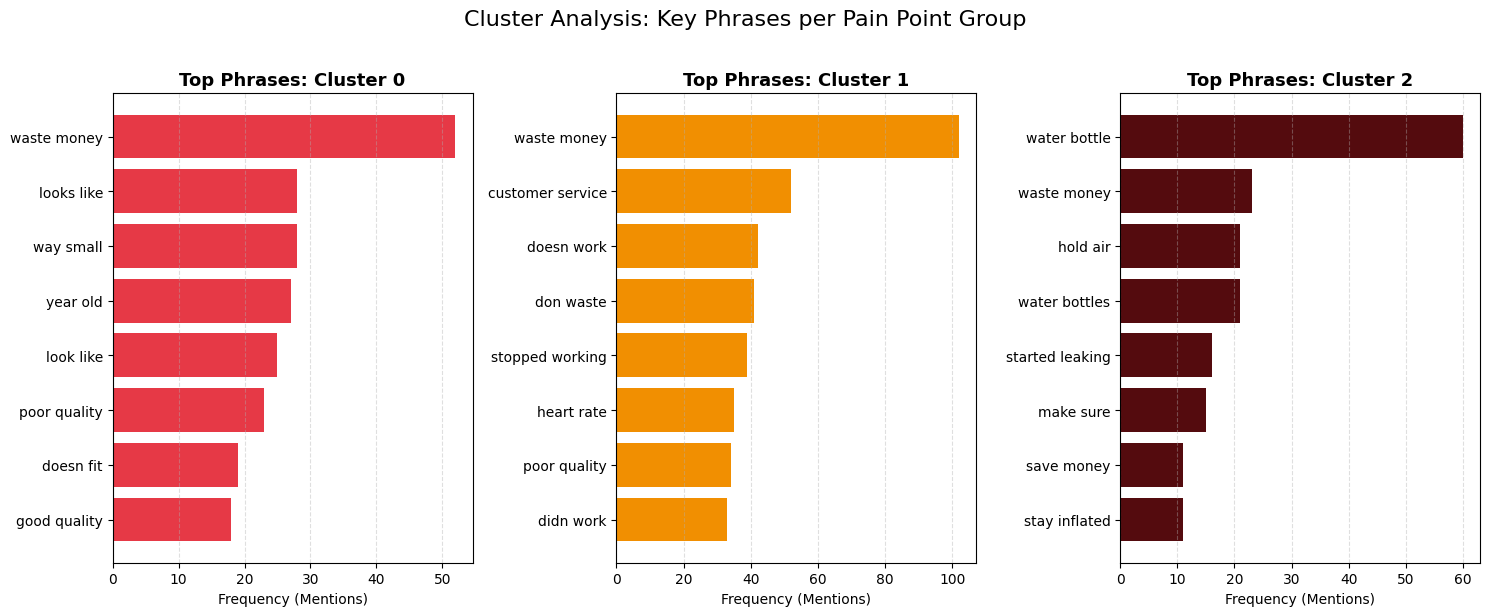

Success: 'Pain_Point_Keywords_Final.png' has been saved without 'br br' noise.


In [37]:
import matplotlib.pyplot as plt

def save_cleaned_keyword_charts(keywords_dict, filename):
    # Set up the visualization style
    plt.figure(figsize=(15, 6))

    # Professional Palette (Matches your Pain Point Scatter Plot)
    # Crimson Red, Amber Gold, Deep Maroon
    bar_colors = ['#E63946', '#F18F01', '#540B0E']

    # List of noise words to filter out
    ignore_list = ['br br', 'br', 'html', 'href', 'http', 'com']

    for i, (cluster, words) in enumerate(keywords_dict.items()):
        plt.subplot(1, 3, i+1)

        # Filter logic: skip noise and keep the top 8 meaningful phrases
        cleaned_words = [w for w in words if w[0].lower() not in ignore_list]

        # Prepare data for plotting
        labels = [w[0] for w in cleaned_words[:8]]
        frequencies = [w[1] for w in cleaned_words[:8]]

        # Create Horizontal Bar Chart
        plt.barh(labels, frequencies, color=bar_colors[i])
        plt.title(f"Top Phrases: {cluster}", fontsize=13, fontweight='bold')
        plt.gca().invert_yaxis()  # Put the highest frequency at the top
        plt.xlabel('Frequency (Mentions)')
        plt.grid(axis='x', linestyle='--', alpha=0.4)

    # Global title for the slide
    plt.suptitle("Cluster Analysis: Key Phrases per Pain Point Group", fontsize=16, y=1.02)

    # Save high-resolution PNG for PowerPoint
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# Execute the saving function
# Replace 'neg_insights' with your keyword dictionary variable
save_cleaned_keyword_charts(neg_insights, "Pain_Point_Keywords_Final.png")

print("Success: 'Pain_Point_Keywords_Final.png' has been saved without 'br br' noise.")

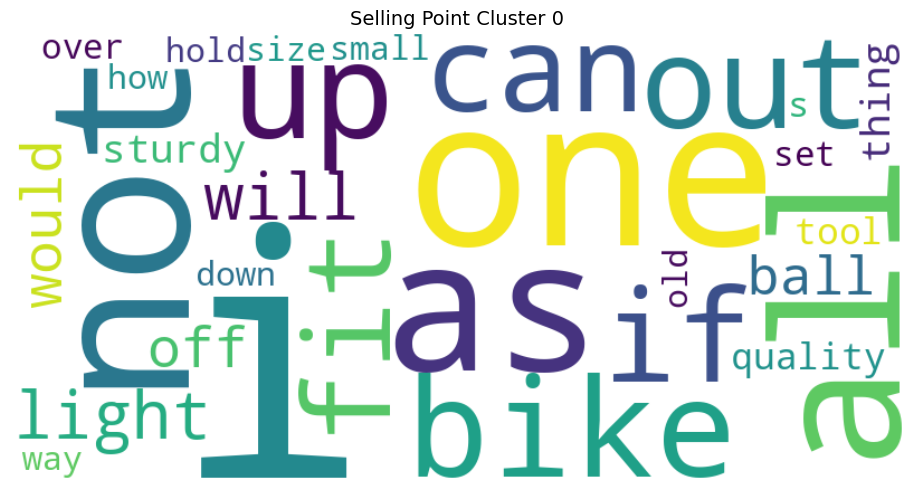

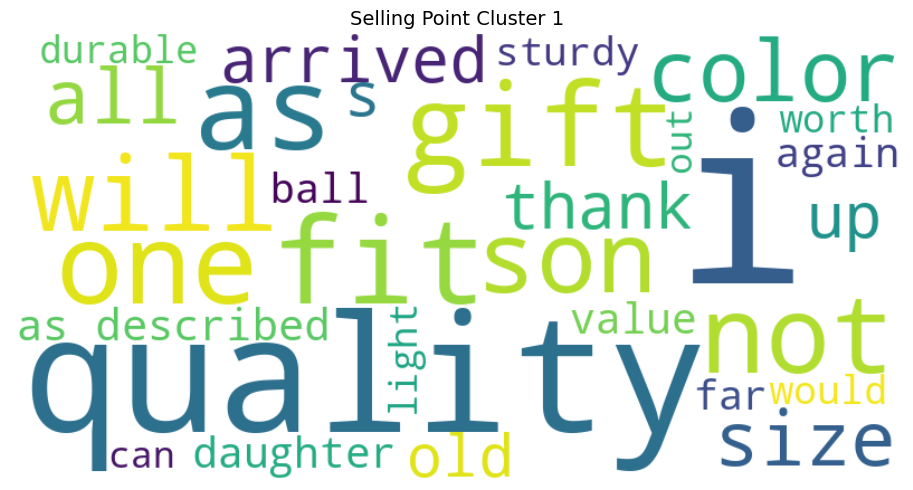

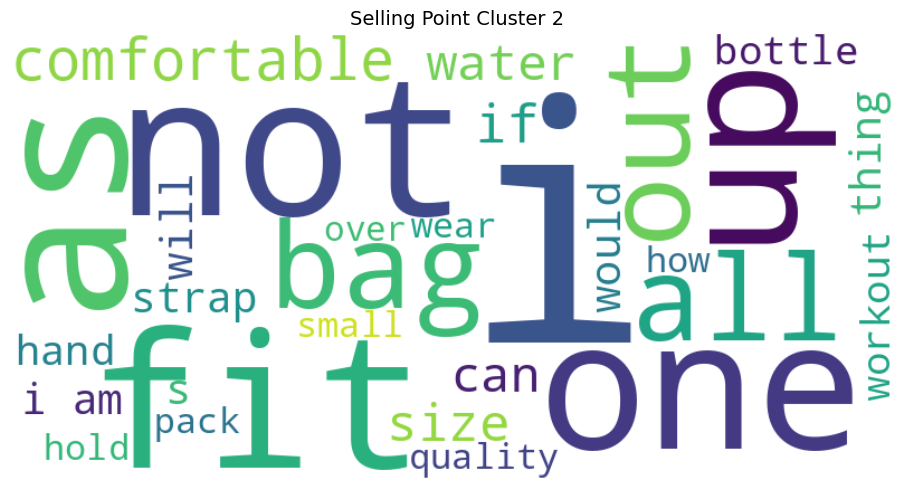

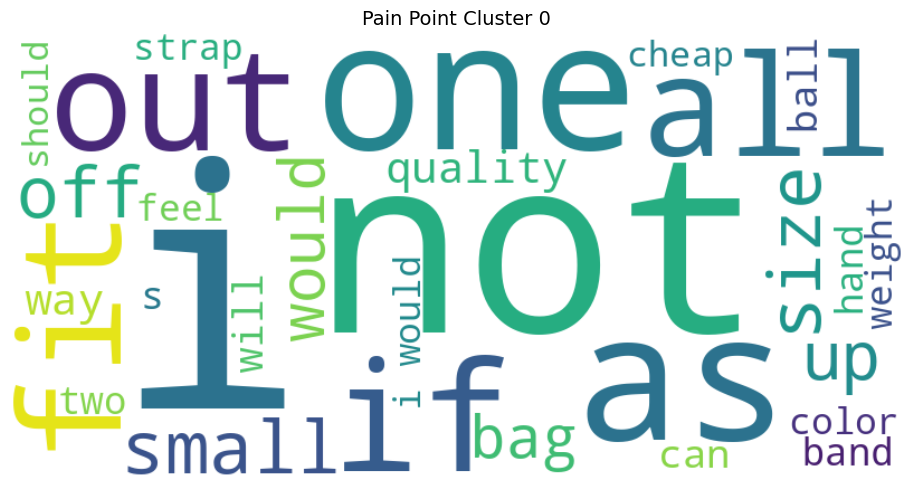

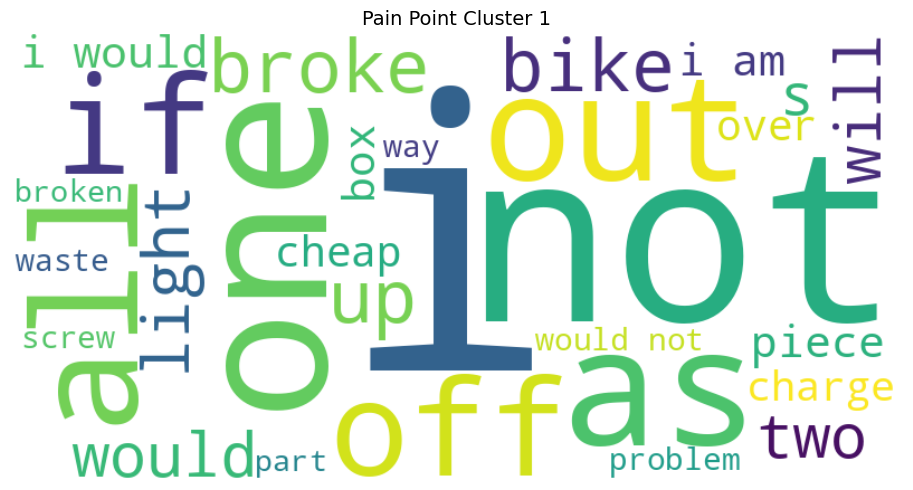

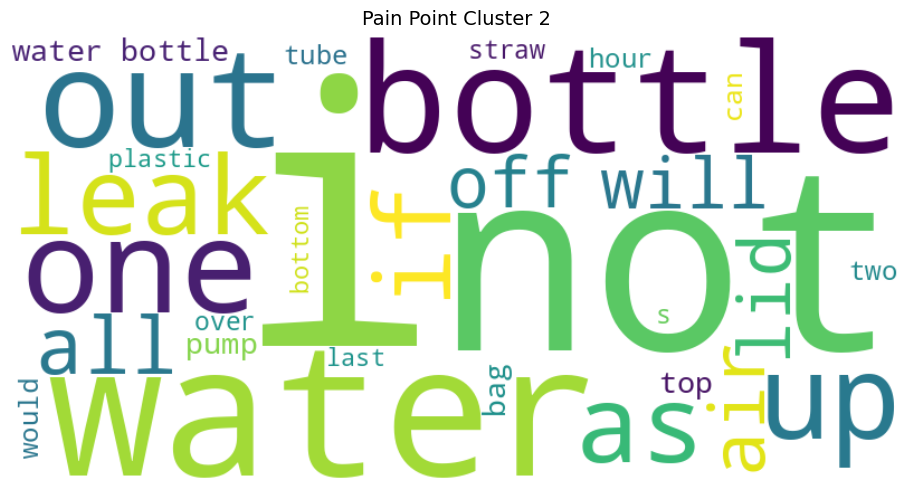

In [38]:
# ==============================================================================
# Generate Clean Word Clouds
# ==============================================================================

from wordcloud import WordCloud

def generate_clean_wordcloud(texts, title, filename, stopwords):
    all_text = " ".join(texts.astype(str))

    # Use extended stop words in word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        max_words=30,
        stopwords=stopwords  # Critical! Add stopwords parameter
    ).generate(all_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

# Convert set to frozenset for wordcloud
stopwords_for_wc = frozenset(extended_stops)

# Generate word clouds for positive clusters
for i in range(3):
    cluster_texts = positive_df[positive_df['cluster'] == i]['text_clean']
    generate_clean_wordcloud(
        cluster_texts,
        f'Selling Point Cluster {i}',
        f'wordcloud_pos_{i}.png',
        stopwords_for_wc
    )

# Generate word clouds for negative clusters
for i in range(3):
    cluster_texts = negative_df[negative_df['cluster'] == i]['text_clean']
    generate_clean_wordcloud(
        cluster_texts,
        f'Pain Point Cluster {i}',
        f'wordcloud_neg_{i}.png',
        stopwords_for_wc
    )

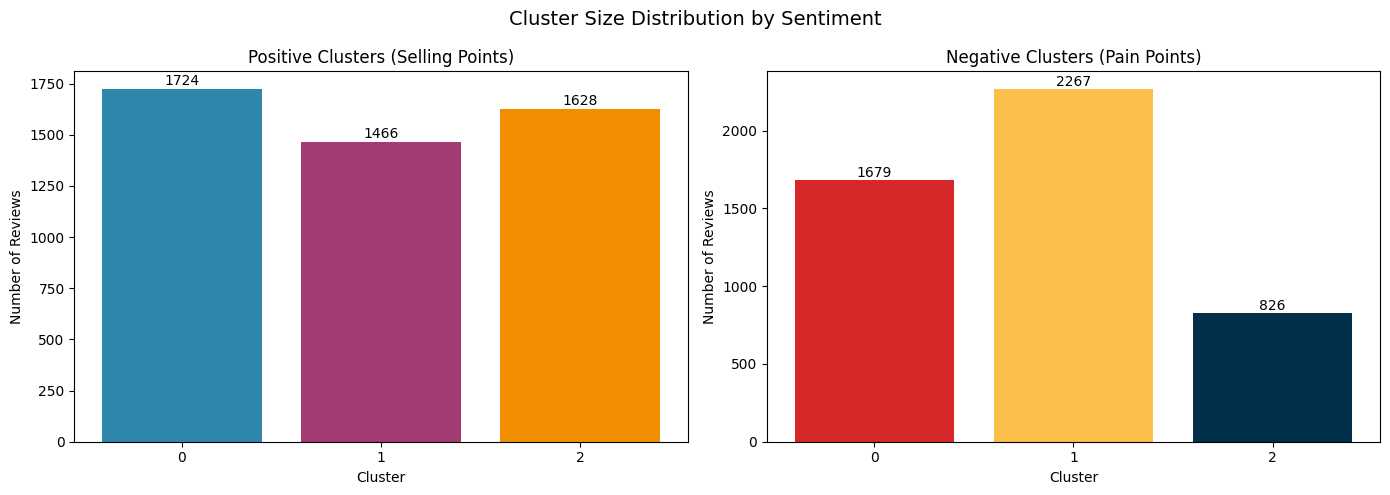

In [ ]:
# ==============================================================================
# Cluster Size Comparison
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Positive clusters
sizes_pos = positive_df['cluster'].value_counts().sort_index()
axes[0].bar(sizes_pos.index, sizes_pos.values, color=['#2E86AB', '#A23B72', '#F18F01'])
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_title('Positive Clusters (Selling Points)', fontsize=12)
axes[0].set_xticks([0, 1, 2])

# Add value labels on bars
for i, v in enumerate(sizes_pos.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

# Negative clusters
sizes_neg = negative_df['cluster'].value_counts().sort_index()
axes[1].bar(sizes_neg.index, sizes_neg.values, color=['#D62828', '#FCBF49', '#003049'])
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of Reviews')
axes[1].set_title('Negative Clusters (Pain Points)', fontsize=12)
axes[1].set_xticks([0, 1, 2])

for i, v in enumerate(sizes_neg.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=10)

plt.suptitle('Cluster Size Distribution by Sentiment', fontsize=14)
plt.tight_layout()
plt.savefig('cluster_size_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Robustness Check
To ensure the clusters identified by BERT are not just random word co-occurrences, we performed a validation step by sampling raw reviews from each cluster.

In [39]:
# ==============================================================================
# VALIDATE PAIN POINT CLUSTER 1 (Broken/Bike Issues)
# ==============================================================================

print("="*60)
print("VALIDATING PAIN POINT CLUSTER 1")
print("="*60)

# Sample 5 random reviews from Cluster 1
sample_reviews = negative_df[negative_df['cluster'] == 1]['text'].sample(5, random_state=42)

print("\n🔍 SAMPLE REVIEWS FROM CLUSTER 1:")
print("-"*50)
for i, review in enumerate(sample_reviews):
    print(f"\nReview {i+1}: {review[:300]}...")

# ==============================================================================
# EXTRACT TOP PHRASES (BIGRAMS) FROM CLUSTER 1
# ==============================================================================

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Get cleaned text from Cluster 1
cluster_texts = negative_df[negative_df['cluster'] == 1]['text_clean'].astype(str)

# Extract bigrams (2-word phrases)
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=20)
bigram_matrix = vectorizer.fit_transform(cluster_texts)

# Get top phrases
bigram_counts = bigram_matrix.sum(axis=0).A1
bigram_names = vectorizer.get_feature_names_out()

# Create and sort dataframe
phrases_df = pd.DataFrame({
    'phrase': bigram_names,
    'count': bigram_counts
}).sort_values('count', ascending=False)

print("\n📊 TOP PHRASES IN CLUSTER 1:")
print("-"*40)
print(phrases_df.head(10).to_string(index=False))

# ==============================================================================
# CHECK SPECIFIC PRODUCT TYPES IN CLUSTER 1
# ==============================================================================

# Check what products are being discussed
print("\n🔍 PRODUCT TYPES IN CLUSTER 1:")
print("-"*40)

product_keywords = ['bike', 'water', 'bottle', 'light', 'ball', 'bag', 'shoe', 'glove']
for kw in product_keywords:
    count = negative_df[negative_df['cluster'] == 1]['text_clean'].str.contains(kw, na=False).sum()
    if count > 0:
        print(f"  {kw}: {count} reviews")

# ==============================================================================
# VALIDATE ALL THREE PAIN POINT CLUSTERS
# ==============================================================================

print("\n" + "="*60)
print("VALIDATING ALL PAIN POINT CLUSTERS")
print("="*60)

for cluster_id in [0, 1, 2]:
    cluster_texts = negative_df[negative_df['cluster'] == cluster_id]['text_clean'].astype(str)

    # Extract bigrams
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=10)
    mat = vec.fit_transform(cluster_texts)
    counts = mat.sum(axis=0).A1
    names = vec.get_feature_names_out()

    print(f"\n{'='*40}")
    print(f"CLUSTER {cluster_id} ({len(negative_df[negative_df['cluster'] == cluster_id])} reviews)")
    print(f"{'='*40}")

    # Top phrases
    print("Top phrases:")
    for i in range(min(5, len(names))):
        print(f"  - {names[i]}: {counts[i]}")

    # Sample one review
    sample = negative_df[negative_df['cluster'] == cluster_id]['text'].iloc[0]
    print(f"\nSample review: {sample[:200]}...")

VALIDATING PAIN POINT CLUSTER 1

🔍 SAMPLE REVIEWS FROM CLUSTER 1:
--------------------------------------------------

Review 1: Hinges did not hold up. Ended up buying the stainless steal hinges....

Review 2: Im returning it cause its didn't  fits and the size it said it fits im. So not upset just wished it would have worked out...

Review 3: comfy and lots of good data, but even after software updates and  almost constant syncing and resetting screen still locks up. Never been hit or dropped.  Will be my last Fitbit product....

Review 4: Unfortunately the bearing was junk out of the box...

Review 5: handle broke easily....

📊 TOP PHRASES IN CLUSTER 1:
----------------------------------------
          phrase  count
     waste money    102
customer service     52
      doesn work     42
       don waste     40
 stopped working     39
      heart rate     35
    poor quality     34
       didn work     33
         don buy     31
       does work     31

🔍 PRODUCT TYPES IN CLUSTER 1:
